# Comparing Performance Patterns in Tested vs. Untested Powerlifting Competition Entries

**Jeff Wu | ICS 604: Applied Data Science | Spring 2026 | University of Hawaii at Manoa**

---

## Introduction  

This study looks at whether powerlifting competition results differ depending on whether the entry was in a tested or untested category. Using the OpenPowerlifting public dataset (~3.8 million records), the analysis compares `TotalKg` and `Dots`, looks at how the tested-entry share changes across performance levels, and tracks the tested-vs-untested gap across age bins.

`TotalKg` is the simplest performance measure in this study because it is just the sum of a lifter's best squat, bench press, and deadlift in one meet. `Dots` is a bodyweight-adjusted strength score, so it helps compare lifters across different body sizes and weight classes.

Understanding where and how performance differs between tested and untested competition contexts has practical value. For athletes and coaches, knowing how performance compares across contexts could help set realistic training benchmarks and goals for specific competition situations. This also matters because tested and untested meets are often discussed as if the difference is obvious, but a data-based comparison can show whether the gap is consistent, small, or dependent on subgroup.

The cleaned base dataset keeps one row per competition result, which matches how OpenPowerlifting records the data.  For the formal research-question analyses, I remove lifters who appear in both tested and untested contexts and replace repeated same-status entries with their mean, leaving one representative row per lifter within each comparison group.

## Analysis Decisions

The following decisions govern the data filtering, grouping, and analysis parameters used throughout this notebook. They are collected here so the later code cells can follow one explicit analysis policy from start to finish.  

| Category | Decision | Value | Rationale |
|---|---|---|---|
| **Data Source** | Source file | `data\openpowerlifting-2026-03-14-dfb517af.csv` [Download from Github](https://github.com/wuj/ics604-final-project/releases/download/v1.0.0/openpowerlifting-2026-03-14.zip) | A saved snapshot of the full OpenPowerlifting database so anyone can re-run this analysis and get the same results |
| **Data Source** | Download date | March 14, 2026 | |
| **Data Source** | Revision | `dfb517af` | |
| **Scope and Filtering** | Raw unit of analysis | One competition entry | Each row is one lifter's result from one competition |
| **Scope and Filtering** | Tested mapping | `"Yes"` marks tested; blank marks untested | Follows how OpenPowerlifting records whether a competition was tested |
| **Scope and Filtering** | Open division allowlist | `Open` only | Focuses on the main adult division with no age or experience restrictions |
| **Scope and Filtering** | Adult rule | Keep `Age >= 18`; if `Age` is missing, drop only `AgeClass` values `5-12`, `13-15`, `16-17` | Removes anyone clearly under 18 but keeps older lifters whose exact age is unknown |
| **Scope and Filtering** | Equipment keep list | `Raw`, `Wraps`, `Single-ply`, `Multi-ply` | Keeps only the four standard equipment categories and drops rare or unclear labels |
| **Scope and Filtering** | Placement denylist | `DQ`, `DD`, `NS` | Drops entries where the lifter was disqualified, failed a drug test, or did not show up |
| **Scope and Filtering** | Event keep rule | `SBD` | Only includes entries where the lifter performed all three lifts (squat, bench, deadlift) |
| **Scope and Filtering** | Valid total rule | `TotalKg` must be present | Every research question needs a valid competition total to work with |
| **Scope and Filtering** | Crossover-lifter rule | Drop any lifter that appears in both tested and untested meets | If someone competed in both tested and untested meets, they are removed so each lifter belongs to only one group |
| **Formal Analysis Units** | RQ1 formal unit | One representative row per lifter, sex, equipment, weight class, and tested status | If a lifter competed multiple times in the same weight class and equipment, their results are averaged into one row |
| **Formal Analysis Units** | RQ2 formal unit | One representative row per lifter, sex, and tested status | Each lifter contributes one average DOTS score so frequent competitors do not count extra |
| **Formal Analysis Units** | RQ3 formal unit | One representative row per lifter, sex, age bin, and tested status (among rows with known age) | If a lifter competed multiple times in the same age range, their results are averaged into one row |
| **Formal Analysis Units** | Repeat-entry rule | Collapse repeated same-status entries with the mean | Averaging is the simplest way to combine multiple competition results into one |
| **Analysis Parameters** | Minimum subgroup count | `30` | Any group with fewer than 30 lifters is too small for reliable comparison and is excluded |
| **Analysis Parameters** | RQ1 metrics | `TotalKg`, `Dots` | TotalKg compares lifters in the same weight class; DOTS adjusts for body weight so different classes can be compared |
| **Analysis Parameters** | RQ1 multiple-testing correction | Bonferroni: alpha / m, where m = number of qualifying subgroup pairs | Controls the family-wise error rate across all RQ1 subgroup tests (NIST/SEMATECH, n.d.) |
| **Analysis Parameters** | RQ2 binning rule | `5` equal-width DOTS bins within sex | Five bins gives enough groups to see a pattern while keeping each bin large enough for the chi-squared test to be valid |
| **Analysis Parameters** | RQ3 age bins | `18-23`, `24-30`, `31-40`, `41-50`, `51-60`, `61+` | Older age groups are wider because fewer lifters compete at those ages |
| **Analysis Parameters** | RQ3 boundary-age rule | Left-closed bins: each bin includes its lower edge but not its upper edge | Under `right=False`, an approximate age like 23.5 falls into `[18, 24)` (the 18-23 bin), while an exact boundary age like 24 falls into `[24, 31)` (the 24-30 bin) |
| **Interpretation** | Interpretation rule | No causal PED claims | A "tested" label only means the competition had drug testing; it does not prove a lifter is drug-free or was actually tested |

## Imports and Configuration  

Load the libraries used throughout the analysis and set display and plotting defaults.

In [125]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:0.4f}".format)

plt.style.use("ggplot")
np.random.seed(604)

DATA_PATH = "data/openpowerlifting-2026-03-14-dfb517af.csv"

## Data Loading  

The data comes from OpenPowerlifting, a community-run project that collects official powerlifting competition results from hundreds of federations around the world and publishes them as a single CSV file under an open license (CC0). The snapshot used here has over 3.8 million rows.

Each row is one competition entry: a single lifter's results from a single meet. The columns cover demographics (sex, age, bodyweight, weight class), performance (best squat, bench press, deadlift, and total in kilograms), context (federation, equipment category, meet date, country), and standardized scores like DOTS. The column that matters most for this study is `Tested`, which records whether the entry came from a tested or untested competition.

**Snapshot used:** Revision `dfb517af`, retrieved March 14, 2026. Using a fixed revision means anyone who downloads the same file will get the same results.

**Download the dataset from Github** and extract the zip file contents to `data/`.  

https://github.com/wuj/ics604-final-project/releases/download/v1.0.0/openpowerlifting-2026-03-14.zip


The cell below loads the raw CSV and confirms the expected shape and columns before anything else is done.

In [126]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError( 
        f"Expected dataset '{os.path.basename(DATA_PATH)}' not found at: {DATA_PATH}\n"
        "Download it from:\n"
        "  https://github.com/wuj/ics604-final-project/releases/download/v1.0.0/openpowerlifting-2026-03-14.zip\n"
        "Then unzip and place the CSV in the data/ directory."
    )

raw_df = pd.read_csv(DATA_PATH, low_memory=False)

print("Data shape:", raw_df.shape)

print("")
print("Columns")
display(raw_df.dtypes.to_frame("dtype"))

print("")
print("Preview:")
display(raw_df.head())

Data shape: (3868570, 42)

Columns


,dtype
Name,str
Sex,str
Event,str
Equipment,str
Age,float64
AgeClass,str
BirthYearClass,str
Division,str
BodyweightKg,float64
WeightClassKg,str



Preview:


,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Glossbrenner,Goodlift,Tested,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName,Sanctioned
0,E.S. Denisenko,F,B,Raw,28.5000,24-34,24-39,Open,67.3000,NaN,NaN,NaN,NaN,NaN,NaN,-40.0000,-45.0000,-45.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
1,I.S. Lebetskaya,F,B,Raw,43.5000,40-44,40-49,Open,73.2000,NaN,NaN,NaN,NaN,NaN,NaN,80.0000,85.0000,90.0000,NaN,90.0000,NaN,NaN,NaN,NaN,NaN,90.0000,1,88.8000,86.8900,76.5000,70.0600,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
2,K. Yakimovich,F,B,Raw,26.5000,24-34,24-39,Open,60.6000,NaN,NaN,NaN,NaN,NaN,NaN,40.0000,42.5000,45.0000,NaN,45.0000,NaN,NaN,NaN,NaN,NaN,45.0000,2,49.5700,49.7900,43.9800,38.4200,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
3,A.G. Golneva,F,B,Raw,19.5000,20-23,19-23,Juniors 17-21,50.3000,NaN,NaN,NaN,NaN,NaN,NaN,32.5000,35.0000,-37.5000,NaN,35.0000,NaN,NaN,NaN,NaN,NaN,35.0000,2,43.6700,44.7600,39.7300,34.5500,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
4,E.V. Marunevskaya,F,B,Raw,19.5000,20-23,19-23,Juniors 17-21,63.7000,NaN,NaN,NaN,NaN,NaN,NaN,40.0000,42.5000,-45.0000,NaN,42.5000,NaN,NaN,NaN,NaN,NaN,42.5000,1,45.4000,45.2600,39.9600,35.2500,NaN,NaN,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes


## Data Inspection

Before filtering anything, I want to see what the raw values actually look like in the columns that matter. OpenPowerlifting pulls records from hundreds of federations, and each one labels things its own way, so columns like `Tested`, `Division`, and `Equipment` might have inconsistent or unexpected values that would quietly skew the results if I just took them at face value.

This cell examines:

- **`Tested` labels:** the field behind every research question. I need to check that the raw values map cleanly to tested vs. untested before using them later.
- **`Division` labels:** division names vary a lot across federations. Only labels that clearly mean unrestricted adult Open competition should be kept, so the most common labels are printed here for a manual look.
- **Missing values in key columns:** columns the analysis depends on are checked for null counts. If too many values are missing, that limits what I can work with or forces a decision about how to handle the gaps.
- **Label frequencies:** value counts for `Equipment`, `Sex`, `Event`, `Place`, and `WeightClassKg` are printed to make sure the expected categories are present and to flag any rare or odd labels.

What I find here shapes both the broad exploratory filter in the next section and the stricter cleaning rules used later.

In [127]:
key_cols = [
    "Tested", "Division", "Equipment", "Sex", "Event", "Place",
    "Age", "WeightClassKg", "TotalKg", "Dots", "Date"
]

print("Number of rows that have missing values in key columns:")
print(raw_df[key_cols].isna().sum())

for col in ["Tested", "Division", "Equipment", "Sex", "Event", "Place", "WeightClassKg"]:
    print(f"\n=== {col} ===")
    print(raw_df[col].value_counts(dropna=False).head(30))

tested_raw = raw_df["Tested"].fillna("")
tested_raw = tested_raw.astype(str)
tested_raw = tested_raw.str.strip()
tested_values = tested_raw.value_counts(dropna=False)

print("")
print("Tested values:")
print(tested_values) 

Number of rows that have missing values in key columns:
Tested            926873
Division            3747
Equipment              0
Sex                    0
Event                  0
Place                  0
Age              1437073
WeightClassKg      57481
TotalKg           262757
Dots              288804
Date                   0
dtype: int64

=== Tested ===
Tested
Yes    2941697
NaN     926873
Name: count, dtype: int64

=== Division ===
Division
Open                     995018
Boys                     526100
Girls                    325102
Juniors                  135709
MR-O                     104007
Sub-Juniors               70374
Amateur Open              70329
Pro Open                  64873
FR-O                      60200
Masters 1                 57580
Juniors 20-23             43931
O                         41598
Masters 2                 41116
M-O                       39638
MR-Jr                     37502
Masters 40-44             27146
Masters 3                 21008
Master

## Preliminary Exploratory Data Analysis (EDA)

Before defining the stricter cleaned dataset for the main analysis, this section produces three exploratory figures to confirm that the patterns motivating RQ1, RQ2, and RQ3 are visible in the data. These are descriptive figures only; they are only meant to show what the data looks like before any inferential testing.

For the EDA, I'm using broader filters (74 Open-like division labels, Raw and Wraps only, no crossover-lifter removal) rather than the stricter cleaned subset used later. This is intentional: during the project proposal phase, the goal was to check whether the data contained patterns worth studying, not to lock down the final comparison groups.

In [128]:
# =============================================================================
# Proposal EDA Subset Setup
# Recreate the broader proposal-era analysis subset from raw_df,
# keeping the constants and filters needed for the three proposal
# figures while leaving the later cleaned df untouched.
# =============================================================================

OPEN_DIVISION_VALUES = {
    "Amateur Open",
    "Amateur Open 18+",
    "Classic Open",
    "DT Open",
    "Elite Amateur Open",
    "Elite Open",
    "Elite Pro Open",
    "F-C-Open",
    "F-E-Open",
    "F-O",
    "F-OPEN",
    "F-Open",
    "FR-O",
    "FW-O",
    "M-C-Open",
    "M-E-Open",
    "M-O",
    "M-OPEN",
    "M-Open",
    "Men's Classic Raw Open",
    "MR-O",
    "MW-O",
    "Men's Open",
    "Men's Raw Open",
    "Men's Raw with Wraps Open",
    "Military Amateur Open",
    "Military Open",
    "Military Pro Open",
    "Men Open",
    "Nauru Open",
    "NTOpen",
    "O",
    "OPEN",
    "OPEN 100",
    "OPEN 100+",
    "OPEN 67.5+",
    "OPEN 82.5",
    "OPEN 90",
    "OPEN U67.5",
    "Open",
    "Open - Femenino",
    "Open - Masculino",
    "Open Amateur",
    "Open Am",
    "Open AWPC",
    "Open NT",
    "Open Pro",
    "Open-DT",
    "OpenDT",
    "Opens",
    "OpenT",
    "Police Amateur Open",
    "Police Pro Open",
    "Police/Fire/Military Amateur Open",
    "Police/Fire/Military Pro Open",
    "POpen",
    "Pro FR-O",
    "Pro FW-O",
    "Pro MR-O",
    "Pro MW-O",
    "Pro Open",
    "Pro TOpen",
    "Raw Open",
    "R Open",
    "retroopen",
    "retrowopen",
    "TOpen",
    "US Open",
    "Women Open",
    "Women's Open",
    "Women's Classic Raw Open",
    "Women's Raw Open",
    "open",
    "wopen",
}

COLOR_TESTED = "#2ecc71"
COLOR_UNTESTED = "#e74c3c"
EDA_N_RQ2_BINS = 30
EDA_MIN_COUNT = 50
KDE_MAX = 500_000
ADULT_MIN_AGE = 18
RQ2_UPPER_PCTILE = 99.5
AGE_BIN_SPECS = [
    ("18-23", 18, 24),
    ("24-30", 24, 31),
    ("31-40", 31, 41),
    ("41-50", 41, 51),
    ("51-60", 51, 61),
    ("61+", 61, None),
]
AGE_LABELS = []
for age_spec in AGE_BIN_SPECS:
    AGE_LABELS.append(age_spec[0])
# Keep the same columns and column order used by the proposal script.
eda_filter_columns = [
    "Sex",
    "Event",
    "Equipment",
    "Age",
    "Division",
    "BodyweightKg",
    "TotalKg",
    "Place",
    "Dots",
    "Tested",
]
eda_df = raw_df.loc[:, eda_filter_columns].copy()

# Standardize the text columns used directly in the filter.
eda_df["Division"] = eda_df["Division"].fillna("").astype(str).str.strip()
eda_df["Tested"] = eda_df["Tested"].fillna("").astype(str).str.strip()

# Apply the broader proposal-era filter to the raw data snapshot.
eda_mask = (
    (eda_df["Event"] == "SBD")
    & (eda_df["TotalKg"].notna())
    & (eda_df["BodyweightKg"].notna())
    & (~eda_df["Place"].isin(["DQ", "DD", "NS"]))
    & (eda_df["Sex"].isin(["M", "F"]))
    & (eda_df["Equipment"].isin(["Raw", "Wraps"]))
    & ((eda_df["Age"].isna()) | (eda_df["Age"] >= ADULT_MIN_AGE))
    & (eda_df["Division"].isin(OPEN_DIVISION_VALUES))
)
eda_df = eda_df.loc[eda_mask].copy()

if eda_df.empty:
    raise ValueError("Filtering produced zero rows. Re-check Division labels and data snapshot.")

# Mark tested and untested entries for the descriptive figures.
eda_df["is_tested"] = eda_df["Tested"] == "Yes"

n_tested = eda_df["is_tested"].sum()
n_untested = (~eda_df["is_tested"]).sum()

print(f"EDA rows after filtering: {len(eda_df):,}")
print(f"Tested rows: {n_tested:,}")
print(f"Untested rows: {n_untested:,}")

EDA rows after filtering: 570,847
Tested rows: 423,982
Untested rows: 146,865


The cell above filters the raw dataset down to adult open-division full-power entries with valid totals, then tags each row as tested or untested. The filter is intentionally broader than the final analysis filter: it keeps 74 Open-like division labels instead of the single exact `"Open"` value used later, and it does not remove crossover lifters. I decided on the wider scope for an exploratory pass because the point is to see overall patterns.

Each of the next three code cells contains all of the computation and plotting logic for the EDA data visualizations.

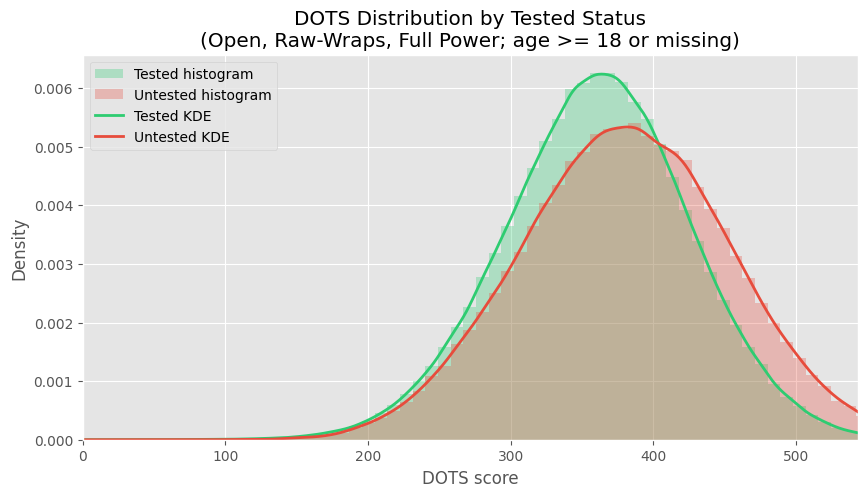

In [129]:
# =============================================================================
# Figure EDA-1: DOTS Distribution by Tested Status
# Recreate the proposal's first descriptive figure with
# density-normalized histograms and KDE curves for the tested
# and untested groups in the broader proposal subset.
# =============================================================================

# Pull the DOTS values for the tested and untested groups.
dots_tested = eda_df.loc[eda_df["is_tested"] & eda_df["Dots"].notna(), "Dots"].values
dots_untested = eda_df.loc[(~eda_df["is_tested"]) & eda_df["Dots"].notna(), "Dots"].values

# Make sure both groups have enough values for a KDE.
if len(dots_tested) < 2 or len(dots_untested) < 2:
    raise ValueError("Figure EDA-1 needs at least two DOTS observations in each group.")

# Build the histogram bins and KDE support range.
all_dots = np.concatenate([dots_tested, dots_untested])
eda_dots_upper = np.percentile(all_dots, 99.5)
eda_dots_hist_bins = np.linspace(0, all_dots.max(), 81)
eda_dots_x_range = np.linspace(0, eda_dots_upper, 500)

# Reproduce the proposal script's reproducible KDE subsampling rule.
if len(dots_tested) > KDE_MAX:
    eda_dots_tested_sample = np.random.choice(dots_tested, KDE_MAX, replace=False)
else:
    eda_dots_tested_sample = dots_tested

if len(dots_untested) > KDE_MAX:
    eda_dots_untested_sample = np.random.choice(dots_untested, KDE_MAX, replace=False)
else:
    eda_dots_untested_sample = dots_untested

# Fit the KDE curves with Silverman's bandwidth rule.
eda_dots_tested_kde = gaussian_kde(eda_dots_tested_sample, bw_method="silverman")
eda_dots_untested_kde = gaussian_kde(eda_dots_untested_sample, bw_method="silverman")
eda_dots_tested_density = eda_dots_tested_kde.evaluate(eda_dots_x_range)
eda_dots_untested_density = eda_dots_untested_kde.evaluate(eda_dots_x_range)

# Use the notebook's existing plotting theme so the EDA figures match the rest of the notebook.
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    dots_tested,
    bins=eda_dots_hist_bins,
    density=True,
    alpha=0.30,
    color=COLOR_TESTED,
    label="Tested histogram",
)
ax.hist(
    dots_untested,
    bins=eda_dots_hist_bins,
    density=True,
    alpha=0.30,
    color=COLOR_UNTESTED,
    label="Untested histogram",
)

ax.plot(
    eda_dots_x_range,
    eda_dots_tested_density,
    color=COLOR_TESTED,
    linewidth=2,
    label="Tested KDE",
)
ax.plot(
    eda_dots_x_range,
    eda_dots_untested_density,
    color=COLOR_UNTESTED,
    linewidth=2,
    label="Untested KDE",
)

ax.set_xlabel("DOTS score")
ax.set_ylabel("Density")
ax.set_title(
    "DOTS Distribution by Tested Status\n"
    "(Open, Raw-Wraps, Full Power; age >= 18 or missing)"
)
ax.legend()
ax.set_xlim(0, eda_dots_upper)
plt.show()

**Figure EDA-1.** A first look at how DOTS scores compare between tested and untested entries before breaking things down by sex, weight class, or equipment.

The histograms are scaled so that their areas match the smooth curves (called KDE curves) layered on top. A KDE curve is just a smoothed-out version of the histogram that makes the overall shape easier to read. In this broader proposal subset, the untested distribution sits farther to the right overall, with a higher center and a heavier right tail than the tested distribution. That visual gap is what made RQ1 worth testing later with stricter subgroup comparisons.

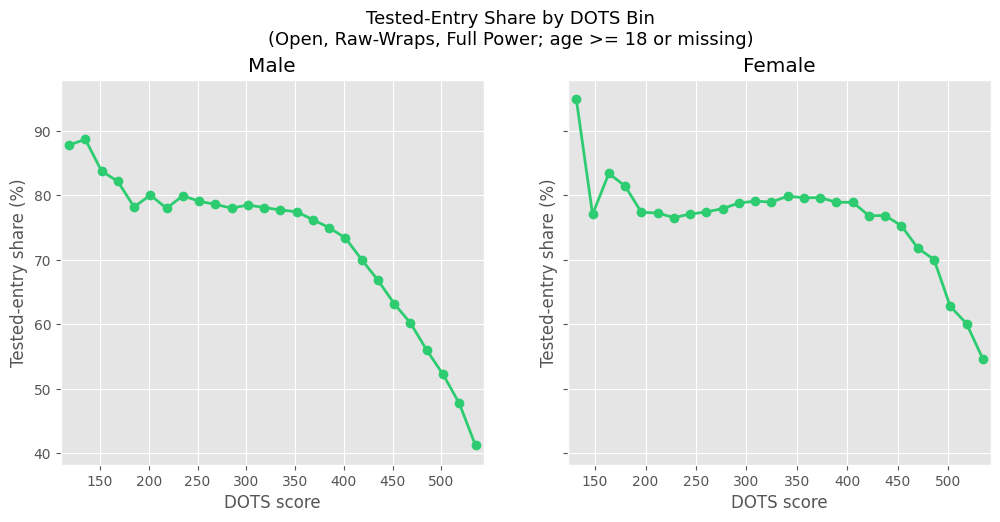

In [130]:
# =============================================================================
# Figure EDA-2: Tested-Entry Share by DOTS Bin
# Recreate the proposal's second descriptive figure by
# computing the tested-entry share across equal-width DOTS
# bins, shown separately for men and women.
# =============================================================================

# Build the binned tested-entry share table for each sex.
eda_gradients = {}
eda_all_tested_pct = []

for sex in ["M", "F"]:
    sex_df = eda_df.loc[eda_df["Sex"] == sex].copy()

    if len(sex_df) == 0:
        raise ValueError(f"Figure EDA-2 has no rows for sex={sex}.")

    # Keep only rows with usable DOTS values for this figure.
    sex_df = sex_df.dropna(subset=["Dots", "is_tested"]).copy()
    dots = sex_df["Dots"].values

    # Cap extreme values at the proposal script's upper percentile.
    upper_cap = np.percentile(dots, RQ2_UPPER_PCTILE)
    sex_df = sex_df.loc[sex_df["Dots"] <= upper_cap].copy()
    dots = sex_df["Dots"].values

    # Build equal-width bin edges and assign each row to a bin.
    bin_edges = np.linspace(dots.min(), upper_cap, EDA_N_RQ2_BINS + 1)
    n_bins_actual = len(bin_edges) - 1
    bin_labels = np.zeros(len(dots), dtype=int)

    for i in range(n_bins_actual):
        lo = bin_edges[i]
        hi = bin_edges[i + 1]

        if i < n_bins_actual - 1:
            in_bin = (dots >= lo) & (dots < hi)
        else:
            in_bin = (dots >= lo) & (dots <= hi)

        bin_labels[in_bin] = i

    sex_df["dots_bin"] = bin_labels

    # Compute the midpoint of each bin for plotting.
    midpoints = []
    for i in range(n_bins_actual):
        midpoint = (bin_edges[i] + bin_edges[i + 1]) / 2
        midpoints.append(midpoint)
    midpoints = np.array(midpoints)

    # Summarize tested counts, total counts, and tested-entry share.
    grouped = sex_df.groupby("dots_bin", sort=True)["is_tested"]
    tested_counts = grouped.sum()
    total_counts = grouped.size()
    pct_tested = tested_counts / total_counts * 100

    gradient = pd.DataFrame({
        "bin_index": tested_counts.index.astype(int),
        "bin_midpoint": midpoints[tested_counts.index.values],
        "tested_pct": pct_tested.values,
        "total_count": total_counts.values,
        "tested_count": tested_counts.values,
    })
    gradient = gradient.loc[gradient["total_count"] >= EDA_MIN_COUNT].reset_index(drop=True)

    if len(gradient) == 0:
        if sex == "M":
            sex_label = "Male"
        else:
            sex_label = "Female"
        raise ValueError(
            f"Figure EDA-2 retained no bins for {sex_label}. Lower EDA_MIN_COUNT or inspect the filters."
        )

    eda_gradients[sex] = gradient
    eda_all_tested_pct.extend(gradient["tested_pct"].to_list())

# Compute the shared y-axis limits across both panels.
y_min = max(0, min(eda_all_tested_pct) - 3)
y_max = min(100, max(eda_all_tested_pct) + 3)

# Use the notebook's existing plotting theme so the EDA figures match the rest of the notebook.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sex_values = ["M", "F"]
sex_labels = ["Male", "Female"]

for i in range(len(sex_values)):
    sex = sex_values[i]
    sex_label = sex_labels[i]
    ax = axes[i]
    gradient = eda_gradients[sex]

    ax.plot(
        gradient["bin_midpoint"].values,
        gradient["tested_pct"].values,
        color=COLOR_TESTED,
        marker="o",
        linewidth=2,
    )

    ax.set_xlabel("DOTS score")
    ax.set_ylabel("Tested-entry share (%)")
    ax.set_title(sex_label)
    ax.set_ylim(y_min, y_max)

    x_span = gradient["bin_midpoint"].iloc[-1] - gradient["bin_midpoint"].iloc[0]
    x_padding = max(2, x_span * 0.02)
    ax.set_xlim(
        gradient["bin_midpoint"].iloc[0] - x_padding,
        gradient["bin_midpoint"].iloc[-1] + x_padding,
    )

fig.suptitle(
    "Tested-Entry Share by DOTS Bin\n"
    "(Open, Raw-Wraps, Full Power; age >= 18 or missing)",
    fontsize=13,
    y=1.02,
)
plt.show()

**Figure EDA-2.** A preliminary look at how the share of tested entries changes as DOTS score increases, shown separately for men and women. The apparent trend motivates the formal analysis in RQ2.

For men, the tested-entry share drops from about 88% in the lowest DOTS bin to about 41% in the highest bin. For women, it drops from about 95% to about 55%. This is still a descriptive view, but it suggests that tested status and performance level may not be independent, which is why the formal analysis in RQ2 uses a chi-squared test to check that relationship.

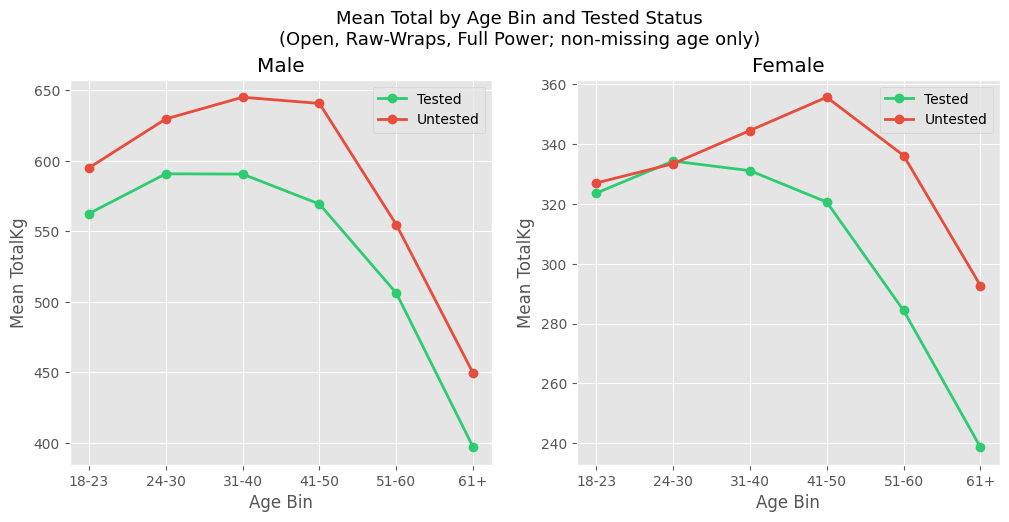

In [131]:
# =============================================================================
# Figure EDA-3: Mean Total by Age Bin and Tested Status
# Recreate the proposal's third descriptive figure by assigning
# broad age bins, summarizing mean TotalKg inside each group,
# and plotting the tested and untested age profiles by sex.
# =============================================================================

# Assign the proposal's age bins with mask-based .loc updates.
eda_age_df = eda_df.copy()
eda_age_df["age_bin"] = ""

for age_spec in AGE_BIN_SPECS:
    label = age_spec[0]
    lower = age_spec[1]
    upper = age_spec[2]

    if upper is None:
        age_mask = eda_age_df["Age"] >= lower
    else:
        age_mask = (eda_age_df["Age"] >= lower) & (eda_age_df["Age"] < upper)

    eda_age_df.loc[age_mask, "age_bin"] = label

eda_age_df = eda_age_df.loc[eda_age_df["age_bin"] != ""].copy()

if eda_age_df.empty:
    raise ValueError("Figure EDA-3 needs non-missing age values after binning.")

# Summarize group counts and mean totals by sex, age bin, and tested status.
eda_age_summary = (
    eda_age_df
    .groupby(["Sex", "age_bin", "is_tested"], sort=False)
    .agg(
        count=("TotalKg", "size"),
        mean_total=("TotalKg", "mean"),
    )
    .reset_index()
)

# Sort the grouped summary into the intended age-bin order.
age_order = {}
for i in range(len(AGE_LABELS)):
    age_order[AGE_LABELS[i]] = i

eda_age_summary["age_order"] = eda_age_summary["age_bin"].map(age_order)
eda_age_summary = eda_age_summary.sort_values(["Sex", "age_order", "is_tested"]).reset_index(drop=True)
eda_age_summary = eda_age_summary.drop(columns="age_order")

# Use the notebook's existing plotting theme so the EDA figures match the rest of the notebook.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
x_positions = np.arange(len(AGE_LABELS))
sex_values = ["M", "F"]
sex_labels = ["Male", "Female"]
tested_values = [True, False]
line_colors = [COLOR_TESTED, COLOR_UNTESTED]
line_labels = ["Tested", "Untested"]

for i in range(len(sex_values)):
    sex = sex_values[i]
    sex_label = sex_labels[i]
    ax = axes[i]
    sex_summary = eda_age_summary.loc[eda_age_summary["Sex"] == sex].copy()

    for j in range(len(tested_values)):
        tested_value = tested_values[j]
        color = line_colors[j]
        label = line_labels[j]
        group_summary = sex_summary.loc[sex_summary["is_tested"] == tested_value].copy()
        y_values = []

        for age_label in AGE_LABELS:
            mean_total = group_summary.loc[group_summary["age_bin"] == age_label, "mean_total"]
            if len(mean_total) == 0:
                y_values.append(np.nan)
            else:
                y_values.append(float(mean_total.iloc[0]))

        ax.plot(
            x_positions,
            y_values,
            color=color,
            marker="o",
            linewidth=2,
            label=label,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(AGE_LABELS)
    ax.set_xlabel("Age Bin")
    ax.set_ylabel("Mean TotalKg")
    ax.set_title(sex_label)
    ax.legend()

fig.suptitle(
    "Mean Total by Age Bin and Tested Status\n"
    "(Open, Raw-Wraps, Full Power; non-missing age only)",
    fontsize=13,
    y=1.02,
)
plt.show()

**Figure EDA-3.** An early look at how mean `TotalKg` compares across age groups for tested and untested entries, split by sex. These patterns motivate RQ3.

Both sexes show a broad inverted-U shape, where mean Total rises into early or middle adulthood and then drops in older bins. The gap between tested and untested entries is not constant across age bins: it is more pronounced in some bins than others. That uneven separation is the reason RQ3 moves to a formal age-bin comparison with bootstrap intervals instead of stopping at this descriptive view.

These three exploratory views confirmed that the research questions are worth pursuing: the DOTS distributions differ visibly between tested and untested entries (RQ1), the tested-entry share drops as DOTS increases (RQ2), and the tested-vs-untested gap varies across age bins (RQ3). The next section builds the stricter cleaned dataset used in the main analysis. After that, we perform the formal testing for the research questions.

## Data Cleaning

The exploratory figures above used a broad filter to check whether the data contained patterns worth studying. For the main analysis, we now switch to a stricter cleaned dataset. Building on the data preparation workflow from class, the steps below define the cleaned base dataset that all later research-question cells will start from:

- **Full-power only:** `Event == "SBD"`
- **Exclude non-valid placements:**  
  - `DQ` - Disqualified  
  - `DD` - Doping Disqualification  
  - `NS` - No-Show
- **Open division only:** exact `Division == "Open"`
- **Sex restricted:** `M` or `F` only
- **Standard equipment:** `Raw`, `Wraps`, `Single-ply`, `Multi-ply`
- **Valid totals:** `TotalKg` must be present
- **Determinable tested status:** `Tested` is either `"Yes"` or blank
- **Adult rule:** keep `Age >= 18`; if `Age` is missing, drop only rows whose `AgeClass` clearly marks a minor (`5-12`, `13-15`, `16-17`)
- **Crossover-lifter rule:** after `is_tested` is created, drop any `Name` that appears in both tested and untested contexts

In [132]:
DIVISION_ALLOWLIST = ["Open"]
EQUIPMENT_ALLOWLIST = ["Raw", "Wraps", "Single-ply", "Multi-ply"]
PLACEMENT_DENYLIST = ["DQ", "DD", "NS"]
DEFINITE_MINOR_AGECLASSES = ["5-12", "13-15", "16-17"]
BOUNDARY_HALF_AGES = [23.5, 30.5, 40.5, 50.5, 60.5]

df = raw_df.copy()

for col in [
    "Name", "Tested", "Division", "Equipment", "Sex", "Event",
    "Place", "WeightClassKg", "AgeClass", "BirthYearClass"
]:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

for col in ["Age", "TotalKg", "Dots"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["Event"] == "SBD"]
df = df[~df["Place"].isin(PLACEMENT_DENYLIST)]
df = df[df["Division"].isin(DIVISION_ALLOWLIST)]
df = df[df["Sex"].isin(["M", "F"])]
df = df[df["Equipment"].isin(EQUIPMENT_ALLOWLIST)]
df = df[df["TotalKg"].notna()]
df = df[df["Tested"].isin(["", "Yes"])].copy()

known_minor_mask = df["Age"] < 18
missing_age_minor_mask = (
    df["Age"].isna() &
    df["AgeClass"].isin(DEFINITE_MINOR_AGECLASSES)
)

df = df[~(known_minor_mask | missing_age_minor_mask)].copy()

df["is_tested"] = df["Tested"].eq("Yes")

status_counts = df.groupby("Name")["is_tested"].nunique()
crossover_names = status_counts[status_counts > 1].index
crossover_removed = df["Name"].isin(crossover_names).sum()
df = df[~df["Name"].isin(crossover_names)].copy()

df.loc[df["WeightClassKg"] == "", "WeightClassKg"] = np.nan
boundary_age_count = df["Age"].isin(BOUNDARY_HALF_AGES).sum()

print("Rows removed because Age < 18:", f"{known_minor_mask.sum():,}")
print("Rows removed because missing AgeClass showed a definite minor:", f"{missing_age_minor_mask.sum():,}")
print("Rows removed from crossover lifters:", f"{crossover_removed:,}")
print("Boundary .5 ages kept for the lower-bin convention:", f"{boundary_age_count:,}")

print("")
print("Tested split:")
display(df["is_tested"].value_counts(dropna=False).to_frame("count"))

print("")
print("Final cleaned subset shape:")
print(df.shape)

print("")
df.to_csv("data/powerlifting-clean.csv", index=False)
print("Saved to data/powerlifting-clean.csv")


Rows removed because Age < 18: 27,587
Rows removed because missing AgeClass showed a definite minor: 1,185
Rows removed from crossover lifters: 99,660
Boundary .5 ages kept for the lower-bin convention: 23,077

Tested split:


,count
is_tested,
True,345679
False,165203



Final cleaned subset shape:
(510882, 43)

Saved to data/powerlifting-clean.csv


The cleaning step reduced the raw file to 510,882 rows, about 13% of the original dataset. Even after that attrition, the cleaned sample is still large, with 345,679 tested rows and 165,203 untested rows, so all three research questions still have enough data to work with. The main coverage problem that remains is age: 28.7% of cleaned rows still have missing `Age`, which is why RQ3 uses fewer rows than RQ1 and RQ2. Removing crossover lifters sharpens the separation between tested and untested competition contexts, but it also narrows the study population to lifters who appear on only one side of that split. These trade-offs matter when interpreting the results and are revisited in the overall conclusion at the end of this notebook.

## Base State Setup

Before moving on to the research questions, this section loads the corrected base dataset, sets the shared constants, and builds the representative lifter-level analysis tables used later in the notebook. I keep those tables separate from the cleaned base data.


In [133]:
df = pd.read_csv("data/powerlifting-clean.csv", low_memory=False)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in ["Age", "TotalKg", "Dots"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

ALPHA = 0.05
MIN_COUNT = 30
N_RQ2_BINS = 5
N_PERMUTATIONS = 10_000
N_BOOTSTRAP = 10_000

AGE_BINS = [18, 24, 31, 41, 51, 61, np.inf]
AGE_LABELS = ["18-23", "24-30", "31-40", "41-50", "51-60", "61+"]
BOUNDARY_HALF_AGES = [23.5, 30.5, 40.5, 50.5, 60.5]

df["age_bin"] = pd.cut(
    df["Age"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False
)

rq1_base_df = (
    df.dropna(subset=["WeightClassKg", "TotalKg", "Dots"])
    .groupby(["Name", "Sex", "Equipment", "WeightClassKg", "is_tested"], as_index=False)
    .agg(
        TotalKg=("TotalKg", "mean"),
        Dots=("Dots", "mean")
    )
)

rq2_base_df = (
    df.dropna(subset=["Dots"])
    .groupby(["Name", "Sex", "is_tested"], as_index=False)
    .agg(Dots=("Dots", "mean"))
)

rq3_base_df = (
    df.dropna(subset=["age_bin", "TotalKg"])
    .groupby(["Name", "Sex", "age_bin", "is_tested"], as_index=False)
    .agg(TotalKg=("TotalKg", "mean"))
)

dots_missing_pct = df["Dots"].isna().mean() * 100
age_missing_pct = df["Age"].isna().mean() * 100
weightclass_missing_pct = df["WeightClassKg"].isna().mean() * 100
boundary_age_count = df["Age"].isin(BOUNDARY_HALF_AGES).sum()

print(f"Rows in cleaned dataset: {len(df):,}")

print("")
print(f"DOTS missing: {dots_missing_pct:.1f}%")
print(f"Age missing: {age_missing_pct:.1f}%")
print(f"WeightClassKg missing: {weightclass_missing_pct:.1f}%")
print(f"Boundary .5 ages kept in the lower bin: {boundary_age_count:,}")

print("")
print("Age-bin preview:")

display(df[["Age", "age_bin", "TotalKg", "Dots"]].head())


Rows in cleaned dataset: 510,882

DOTS missing: 0.9%
Age missing: 28.7%
WeightClassKg missing: 0.9%
Boundary .5 ages kept in the lower bin: 23,077

Age-bin preview:


,Age,age_bin,TotalKg,Dots
0,30.0000,24-30,202.5000,271.4400
1,29.0000,24-30,247.5000,293.2300
2,28.0000,24-30,250.0000,269.1400
3,23.5000,18-23,495.0000,368.9200
4,25.0000,24-30,597.5000,410.5000


## Analysis Coverage Checks

Before proceeding to the research questions, this section performs a few final checks to confirm whether the representative lifter-level analysis tables support the planned comparisons.

1. **RQ1 subgroup support:** RQ1 uses one representative row per `Name x Sex x Equipment x WeightClassKg x is_tested`. Each `Sex x Equipment x WeightClassKg` subgroup still needs enough tested and untested lifters on both sides of the comparison.
2. **RQ2 expected counts:** RQ2 uses one representative row per `Name x Sex x is_tested`, then builds 5 equal-width `Dots` bins within sex. The chi-squared test still needs expected counts of at least 5 in every active cell.
3. **RQ3 age-bin coverage:** RQ3 uses one representative row per `Name x Sex x age_bin x is_tested` among rows with known age / assigned age bin. Each `Sex x age_bin` cell still needs enough tested and untested representative rows for the bootstrap gap comparison.

The supported subgroup tables created here are the ones used in the formal analysis cells below.


In [134]:
# RQ1 support: representative lifter-status rows inside each subgroup.

rq1_counts = (
    rq1_base_df
    .groupby(["Sex", "Equipment", "WeightClassKg", "is_tested"])
    .size()
    .reset_index(name="n")
)

rq1_tested = (
    rq1_counts[rq1_counts["is_tested"] == True]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_tested"})
)

rq1_untested = (
    rq1_counts[rq1_counts["is_tested"] == False]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_untested"})
)

rq1_pairs = pd.merge(
    rq1_tested,
    rq1_untested,
    on=["Sex", "Equipment", "WeightClassKg"],
    how="inner"
)

rq1_supported_keys = rq1_pairs[
    (rq1_pairs["n_tested"] >= MIN_COUNT) &
    (rq1_pairs["n_untested"] >= MIN_COUNT)
].copy()

rq1_supported_df = pd.merge(
    rq1_base_df,
    rq1_supported_keys[["Sex", "Equipment", "WeightClassKg"]].drop_duplicates(),
    on=["Sex", "Equipment", "WeightClassKg"],
    how="inner"
)

print("RQ1 representative rows with WeightClassKg, TotalKg, and DOTS:", f"{len(rq1_base_df):,}")
print("RQ1 subgroup pairs with both tested and untested rows:", len(rq1_pairs))
print(f"RQ1 subgroup pairs meeting MIN_COUNT={MIN_COUNT}:", len(rq1_supported_keys))

# RQ2 support: keep all representative rows, then check expected counts.

rq2_analysis_df = rq2_base_df.copy()

print("\nRQ2 representative rows:", f"{len(rq2_analysis_df):,}")

for sex in ["M", "F"]:
    sex_df = rq2_analysis_df[rq2_analysis_df["Sex"] == sex].copy()

    bin_edges = np.linspace(
        sex_df["Dots"].min(),
        sex_df["Dots"].max(),
        N_RQ2_BINS + 1
    )

    sex_df["dots_bin"] = pd.cut(
        sex_df["Dots"],
        bins=bin_edges,
        include_lowest=True
    )

    # Count rows in each (dots_bin, is_tested) group, then pivot so
    # each tested status becomes its own column. fill_value=0 means
    # any bin with no rows for a status gets a zero instead of NaN.
    contingency = (
        sex_df.groupby(["dots_bin", "is_tested"])
        .size()
        .unstack(fill_value=0)
    )
    # If a column is missing, add it with zeros so both columns always exist.
    if True not in contingency.columns:
        contingency[True] = 0
    if False not in contingency.columns:
        contingency[False] = 0
    contingency = contingency[contingency.sum(axis=1) > 0]

    _, _, _, expected = stats.chi2_contingency(contingency)

    print(f"\nRQ2 support for sex={sex}")
    print(f"  active bins: {len(contingency)}")
    print(f"  all expected counts >= 5: {(expected >= 5).all()}")
    print(f"  minimum expected count: {expected.min():.2f}")

# RQ3 support: representative lifter-status rows inside each sex x age_bin cell.

rq3_counts = (
    rq3_base_df
    .groupby(["Sex", "age_bin", "is_tested"])
    .size()
    .reset_index(name="n")
)

rq3_tested = (
    rq3_counts[rq3_counts["is_tested"] == True]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_tested"})
)

rq3_untested = (
    rq3_counts[rq3_counts["is_tested"] == False]
    .drop(columns="is_tested")
    .rename(columns={"n": "n_untested"})
)

rq3_pairs = pd.merge(
    rq3_tested,
    rq3_untested,
    on=["Sex", "age_bin"],
    how="inner"
)

rq3_supported = rq3_pairs[
    (rq3_pairs["n_tested"] >= MIN_COUNT) &
    (rq3_pairs["n_untested"] >= MIN_COUNT)
].copy()

rq3_supported_df = pd.merge(
    rq3_base_df,
    rq3_supported[["Sex", "age_bin"]].drop_duplicates(),
    on=["Sex", "age_bin"],
    how="inner"
)

print("\nRQ3 representative rows with age_bin and TotalKg:", f"{len(rq3_base_df):,}")
print("RQ3 sex-age pairs with both tested and untested rows:", len(rq3_pairs))
print(f"RQ3 sex-age pairs meeting MIN_COUNT={MIN_COUNT}:", len(rq3_supported))

print("")
print("RQ3 supported cells preview:")
display(rq3_supported.sort_values(["Sex", "age_bin"]))


RQ1 representative rows with WeightClassKg, TotalKg, and DOTS: 295,718
RQ1 subgroup pairs with both tested and untested rows: 168
RQ1 subgroup pairs meeting MIN_COUNT=30: 78

RQ2 representative rows: 225,578

RQ2 support for sex=M
  active bins: 5
  all expected counts >= 5: True
  minimum expected count: 83.46

RQ2 support for sex=F
  active bins: 5
  all expected counts >= 5: True
  minimum expected count: 7.93

RQ3 representative rows with age_bin and TotalKg: 176,349
RQ3 sex-age pairs with both tested and untested rows: 12
RQ3 sex-age pairs meeting MIN_COUNT=30: 12

RQ3 supported cells preview:


,Sex,age_bin,n_tested,n_untested
0,F,18-23,11045,1968
1,F,24-30,14265,7534
2,F,31-40,8508,4904
3,F,41-50,2170,1048
4,F,51-60,662,289
5,F,61+,181,84
6,M,18-23,29890,6497
7,M,24-30,32031,18599
8,M,31-40,17140,11091
9,M,41-50,4009,1903


These coverage checks show that the planned analyses are feasible on the cleaned data. RQ1 retains 78 subgroup pairs with at least 30 representative rows on both the tested and untested sides. RQ2 passes the chi-squared expected-count rule for both sexes, with every active expected cell above the usual minimum. RQ3 keeps all 12 `Sex x age_bin` cells at the same minimum-count threshold. Multi-ply drops out because none of its subgroup pairs met the support rule. In short, the comparisons promised in the proposal can be carried out on the cleaned sample.

## RQ1: Natty or Not? (Main Performance Comparison)

**Do untested entries tend to show higher `TotalKg` and `Dots` scores than tested entries?**

RQ1 uses one representative row per `Name x Sex x Equipment x WeightClassKg x is_tested`, where repeated same-status entries are collapsed to a mean `TotalKg` and mean `Dots` value first. Subgroups with fewer than 30 representative rows on either side are excluded so that both the bootstrap and permutation procedures have enough data to work with.

**Hypotheses:**

- **H0:** Untested entries do not have higher mean `Dots`/`TotalKg` than tested entries within the same subgroup.
- **Ha:** Untested entries have higher mean `Dots`/`TotalKg` (one-sided).

For each qualifying subgroup `g`, let `mu_NT,g` and `mu_T,g` be the population means for untested and tested representative rows. The hypotheses apply to both `TotalKg` and `Dots`:

`H0: mu_NT,g = mu_T,g` (no difference between groups)

`Ha: mu_NT,g > mu_T,g` (untested mean is higher; one-sided)

Because `Dots` and `TotalKg` are nearly proportional within a single weight class, the two metrics produce identical significance outcomes across all subgroups.

**Approach:**

For each qualifying subgroup the untested-minus-tested gap is assessed three ways: a 95% bootstrap CI (10,000 resamples, percentile method) for direction and size; a one-sided permutation test (10,000 shuffles) for significance; and a one-sided Welch t-test as a parametric cross-check. Both `TotalKg` and `Dots` are compared, though within a single weight class the two metrics are nearly proportional because bodyweight varies little.


In [135]:
# =============================================================================
# RQ1 Summary Table
# For each Sex x Equipment x WeightClassKg subgroup, compute the mean
# TotalKg and DOTS on the tested and untested sides, then compute
# the raw performance gap (untested minus tested) for each metric.
# =============================================================================

# Build one row per subgroup/status with counts and average scores.
summary = (
    rq1_supported_df
    .groupby(["Sex", "Equipment", "WeightClassKg", "is_tested"])
    .agg(
        n=("TotalKg", "size"),
        mean_total=("TotalKg", "mean"),
        mean_dots=("Dots", "mean")
    )
    .reset_index()
)

# Keep only the tested side so it is easy to compare later.
tested = (
    summary[summary["is_tested"] == True]
    .drop(columns="is_tested")
    .rename(columns={
        "n": "n_tested",
        "mean_total": "mean_total_tested",
        "mean_dots": "mean_dots_tested"
    })
)

# Keep only the untested side so it lines up with the tested table.
untested = (
    summary[summary["is_tested"] == False]
    .drop(columns="is_tested")
    .rename(columns={
        "n": "n_untested",
        "mean_total": "mean_total_untested",
        "mean_dots": "mean_dots_untested"
    })
)

# Put the tested and untested subgroup summaries side by side.
rq1_gap_table = pd.merge(
    tested,
    untested,
    on=["Sex", "Equipment", "WeightClassKg"],
    how="inner"
)

rq1_gap_table["gap_total"] = (
    rq1_gap_table["mean_total_untested"] - rq1_gap_table["mean_total_tested"]
)
rq1_gap_table["gap_dots"] = (
    rq1_gap_table["mean_dots_untested"] - rq1_gap_table["mean_dots_tested"]
)

print(f"Qualifying RQ1 subgroup pairs at MIN_COUNT={MIN_COUNT}: {len(rq1_gap_table)}")
display(rq1_gap_table.sort_values(["Sex", "Equipment", "WeightClassKg"]).reset_index(drop=True))

Qualifying RQ1 subgroup pairs at MIN_COUNT=30: 78


,Sex,Equipment,WeightClassKg,n_tested,mean_total_tested,mean_dots_tested,n_untested,mean_total_untested,mean_dots_untested,gap_total,gap_dots
0,F,Raw,100,523,340.7065,296.5468,352,345.8113,300.2727,5.1048,3.7259
1,F,Raw,110,209,358.3553,299.1388,231,354.7993,296.5978,-3.5560,-2.5410
2,F,Raw,110+,208,367.4075,292.7958,118,371.0880,296.4365,3.6805,3.6407
3,F,Raw,44,56,211.4256,294.4768,77,208.7466,291.6809,-2.6790,-2.7959
4,F,Raw,48,229,240.7885,315.8990,230,243.4511,319.0417,2.6626,3.1427
5,F,Raw,52,2752,264.8543,327.7442,608,259.6457,321.3996,-5.2086,-6.3447
6,F,Raw,56,691,270.2071,317.5617,1039,275.6582,324.4382,5.4511,6.8765
7,F,Raw,57,3839,287.4058,334.2550,79,280.3956,327.6501,-7.0102,-6.6048
8,F,Raw,60,990,283.4787,318.2268,1629,292.4281,328.3535,8.9494,10.1266
9,F,Raw,63,5468,303.2615,331.6842,125,294.8507,324.0537,-8.4108,-7.6305


In [136]:
# =============================================================================
# RQ1 Tests
# For each subgroup, test whether untested entries score higher than
# tested entries using bootstrap CIs, permutation tests, and Welch's
# t-test on both TotalKg and DOTS.
# =============================================================================

def test_performance_gap(tested_vals, untested_vals):
    observed_gap = untested_vals.mean() - tested_vals.mean()

    # Bootstrap confidence interval (percentile method)
    # Resample each group with replacement, recompute the gap each time,
    # then take the 2.5th and 97.5th percentiles as the 95% CI bounds.
    bootstrap_gaps = []
    for i in range(N_BOOTSTRAP):
        bootstrap_tested = np.random.choice(tested_vals, size=len(tested_vals), replace=True)
        bootstrap_untested = np.random.choice(untested_vals, size=len(untested_vals), replace=True)
        bootstrap_gaps.append(bootstrap_untested.mean() - bootstrap_tested.mean())

    bootstrap_gaps = np.array(bootstrap_gaps)
    ci_low, ci_high = np.percentile(bootstrap_gaps, [2.5, 97.5])

    # Permutation testing
    # Concatenate the two samples, shuffle the combined data, split into
    # two new groups, and recompute the gap each time. The one-sided
    # p-value is the fraction of shuffled gaps that are at least as large
    # as the observed gap.
    all_data = np.concatenate([untested_vals, tested_vals])
    n_untested = len(untested_vals)
    permutation_gaps = []
    for i in range(N_PERMUTATIONS):
        shuffled = all_data.copy()
        np.random.shuffle(shuffled)
        permutation_gaps.append(shuffled[:n_untested].mean() - shuffled[n_untested:].mean())

    permutation_gaps = np.array(permutation_gaps)
    p_perm = np.mean(permutation_gaps >= observed_gap)

    # Welch's t-test
    # Independent-samples t-test without assuming equal variances.
    # The alternative="greater" parameter is a built-in scipy option that makes
    # the test one-sided, matching Ha: mean(untested) > mean(tested).
    welch = stats.ttest_ind(
        untested_vals,
        tested_vals,
        equal_var=False,
        alternative="greater",
    )

    return observed_gap, ci_low, ci_high, p_perm, welch.statistic, welch.pvalue

rq1_results = []

for (sex, equipment, weight_class), group in rq1_supported_df.groupby(["Sex", "Equipment", "WeightClassKg"]):
    tested_group = group[group["is_tested"] == True]
    untested_group = group[group["is_tested"] == False]

    tested_total = tested_group["TotalKg"].dropna().values
    untested_total = untested_group["TotalKg"].dropna().values
    tested_dots = tested_group["Dots"].dropna().values
    untested_dots = untested_group["Dots"].dropna().values

    total_gap, total_lo, total_hi, total_p_perm, total_t, total_p_welch = test_performance_gap(
        tested_total,
        untested_total
    )

    dots_gap, dots_lo, dots_hi, dots_p_perm, dots_t, dots_p_welch = test_performance_gap(
        tested_dots,
        untested_dots
    )

    rq1_results.append({
        "Sex": sex,
        "Equipment": equipment,
        "WeightClassKg": weight_class,
        "n_tested": len(tested_total),
        "n_untested": len(untested_total),
        "gap_total": total_gap,
        "gap_total_ci_low": total_lo,
        "gap_total_ci_high": total_hi,
        "gap_total_perm_p": total_p_perm,
        "gap_total_welch_t": total_t,
        "gap_total_welch_p": total_p_welch,
        "gap_dots": dots_gap,
        "gap_dots_ci_low": dots_lo,
        "gap_dots_ci_high": dots_hi,
        "gap_dots_perm_p": dots_p_perm,
        "gap_dots_welch_t": dots_t,
        "gap_dots_welch_p": dots_p_welch
    })

rq1_results = pd.DataFrame(rq1_results)

print(f"RQ1 formal-test subgroups analyzed: {len(rq1_results)}")
display(rq1_results.sort_values(["Sex", "Equipment", "WeightClassKg"]).reset_index(drop=True))

RQ1 formal-test subgroups analyzed: 78


,Sex,Equipment,WeightClassKg,n_tested,n_untested,gap_total,gap_total_ci_low,gap_total_ci_high,gap_total_perm_p,gap_total_welch_t,gap_total_welch_p,gap_dots,gap_dots_ci_low,gap_dots_ci_high,gap_dots_perm_p,gap_dots_welch_t,gap_dots_welch_p
0,F,Raw,100,523,352,5.1048,-4.6965,14.7663,0.1443,1.0209,0.1538,3.7259,-4.7164,12.2735,0.1818,0.8619,0.1945
1,F,Raw,110,209,231,-3.5560,-17.0458,10.4488,0.6908,-0.5068,0.6937,-2.5410,-13.8896,8.8466,0.6640,-0.4352,0.6682
2,F,Raw,110+,208,118,3.6805,-13.3513,21.3459,0.3298,0.4165,0.3387,3.6407,-10.1734,17.5325,0.3041,0.5158,0.3032
3,F,Raw,44,56,77,-2.6790,-19.0529,13.4099,0.6267,-0.3166,0.6239,-2.7959,-25.7545,19.9033,0.5917,-0.2388,0.5942
4,F,Raw,48,229,230,2.6626,-5.5108,10.7103,0.2666,0.6363,0.2625,3.1427,-7.4197,13.7202,0.2786,0.5771,0.2821
5,F,Raw,52,2752,608,-5.2086,-9.5281,-0.8924,0.9864,-2.3883,0.9914,-6.3447,-11.6008,-0.8675,0.9846,-2.3702,0.9910
6,F,Raw,56,691,1039,5.4511,0.4445,10.6007,0.0183,2.1282,0.0167,6.8765,0.9406,12.8489,0.0106,2.2988,0.0108
7,F,Raw,57,3839,79,-7.0102,-17.8575,3.9466,0.8594,-1.2674,0.8957,-6.6048,-19.0406,5.8959,0.8028,-1.0347,0.8481
8,F,Raw,60,990,1629,8.9494,4.8775,13.1646,0.0000,4.2264,0.0000,10.1266,5.5008,14.8571,0.0000,4.2754,0.0000
9,F,Raw,63,5468,125,-8.4108,-17.0625,0.2272,0.9428,-1.8994,0.9702,-7.6305,-17.0254,1.6730,0.9074,-1.6008,0.9441


The table above listed the raw untested-minus-tested gap for `TotalKg` and `Dots` in each of the 78 qualifying subgroups, and those raw gaps point in both directions. Those gaps were then tested with bootstrap intervals, one-sided permutation tests, and one-sided Welch tests. The outputs below compress those results into direction counts, an equipment breakdown, and effect-size context.

Before summarizing the RQ1 results, it helps to adjust the significance threshold for the fact that RQ1 runs many subgroup tests at once. The ICS 604 course material defines `alpha` as the chance of a Type I error on one test, so `alpha = 0.05` means a 5% false-positive risk for one comparison. RQ1 runs 78 subgroup comparisons, so using 0.05 for every subgroup would make the chance of at least one false positive across the whole set much larger than 5%.

That overall chance is called the **family-wise error rate**, which means the chance of at least one false positive across the full family of tests. To keep that family-wise error rate at 5%, Bonferroni's method divides `alpha` by the number of tests (NIST/SEMATECH, n.d.). Here the arithmetic is:

`0.05 / 78 = 0.000641`

That corrected threshold is used for the formal RQ1 p-value decisions below. The bootstrap confidence intervals still describe the direction and size of the subgroup gaps, so those descriptive summaries do not change under the Bonferroni correction.


In [137]:
# =============================================================================
# RQ1 Results Summary
# Count how many of the 78 subgroups show a significant untested
# advantage by each test (Welch, permutation) and by bootstrap CI
# direction, for both TotalKg and DOTS.
# =============================================================================

n_subgroups = len(rq1_results)
bonferroni_alpha = ALPHA / n_subgroups

# TotalKg: tally significance and CI direction across all subgroups.
total_positive = (rq1_results["gap_total"] > 0).sum()
total_sig_welch = (rq1_results["gap_total_welch_p"] < ALPHA).sum()
total_sig_perm = (rq1_results["gap_total_perm_p"] < ALPHA).sum()
total_sig_both = ((rq1_results["gap_total_welch_p"] < ALPHA) & (rq1_results["gap_total_perm_p"] < ALPHA)).sum()
total_sig_welch_bonf = (rq1_results["gap_total_welch_p"] < bonferroni_alpha).sum()
total_sig_perm_bonf = (rq1_results["gap_total_perm_p"] < bonferroni_alpha).sum()
total_sig_both_bonf = ((rq1_results["gap_total_welch_p"] < bonferroni_alpha) & (rq1_results["gap_total_perm_p"] < bonferroni_alpha)).sum()
total_ci_above_zero = (rq1_results["gap_total_ci_low"] > 0).sum()
total_ci_below_zero = (rq1_results["gap_total_ci_high"] < 0).sum()
total_ci_includes_zero = n_subgroups - total_ci_above_zero - total_ci_below_zero

# DOTS: perform the same tallies for the DOTS metric.
dots_positive = (rq1_results["gap_dots"] > 0).sum()
dots_sig_welch = (rq1_results["gap_dots_welch_p"] < ALPHA).sum()
dots_sig_perm = (rq1_results["gap_dots_perm_p"] < ALPHA).sum()
dots_sig_both = ((rq1_results["gap_dots_welch_p"] < ALPHA) & (rq1_results["gap_dots_perm_p"] < ALPHA)).sum()
dots_sig_welch_bonf = (rq1_results["gap_dots_welch_p"] < bonferroni_alpha).sum()
dots_sig_perm_bonf = (rq1_results["gap_dots_perm_p"] < bonferroni_alpha).sum()
dots_sig_both_bonf = ((rq1_results["gap_dots_welch_p"] < bonferroni_alpha) & (rq1_results["gap_dots_perm_p"] < bonferroni_alpha)).sum()
dots_ci_above_zero = (rq1_results["gap_dots_ci_low"] > 0).sum()
dots_ci_below_zero = (rq1_results["gap_dots_ci_high"] < 0).sum()
dots_ci_includes_zero = n_subgroups - dots_ci_above_zero - dots_ci_below_zero

total_perm_matches_dots = (
    (rq1_results["gap_total_perm_p"] < bonferroni_alpha)
    == (rq1_results["gap_dots_perm_p"] < bonferroni_alpha)
).all()
total_welch_matches_dots = (
    (rq1_results["gap_total_welch_p"] < bonferroni_alpha)
    == (rq1_results["gap_dots_welch_p"] < bonferroni_alpha)
).all()

print("RQ1 Results Summary")
print("=" * 65)
print(f"Subgroups tested: {n_subgroups}")
print(f"Bonferroni threshold: {ALPHA:.2f} / {n_subgroups} = {bonferroni_alpha:.6f}")

print("")
print("Bonferroni-corrected tallies")
print("")
print("TotalKg (untested minus tested):")
print(f"  Gap positive (mean difference > 0):               {total_positive} of {n_subgroups}")
print(f"  Significant by Welch:                             {total_sig_welch_bonf} of {n_subgroups}")
print(f"  Significant by permutation:                       {total_sig_perm_bonf} of {n_subgroups}")
print(f"  Significant by both tests:                        {total_sig_both_bonf} of {n_subgroups}")

print("")
print("DOTS (untested minus tested):")
print(f"  Gap positive (mean difference > 0):               {dots_positive} of {n_subgroups}")
print(f"  Significant by Welch:                             {dots_sig_welch_bonf} of {n_subgroups}")
print(f"  Significant by permutation:                       {dots_sig_perm_bonf} of {n_subgroups}")
print(f"  Significant by both tests:                        {dots_sig_both_bonf} of {n_subgroups}")

print("")
print("Uncorrected tallies (alpha = 0.05)")
print("")
print("TotalKg (untested minus tested):")
print(f"  Significant by Welch:                             {total_sig_welch} of {n_subgroups}")
print(f"  Significant by permutation:                       {total_sig_perm} of {n_subgroups}")
print(f"  Significant by both tests:                        {total_sig_both} of {n_subgroups}")

print("")
print("DOTS (untested minus tested):")
print(f"  Significant by Welch:                             {dots_sig_welch} of {n_subgroups}")
print(f"  Significant by permutation:                       {dots_sig_perm} of {n_subgroups}")
print(f"  Significant by both tests:                        {dots_sig_both} of {n_subgroups}")

print("")
print("Bootstrap 95% CI direction counts (descriptive)")
print("")
print("TotalKg:")
print(f"  CI above zero:                                    {total_ci_above_zero} of {n_subgroups}")
print(f"  CI below zero:                                    {total_ci_below_zero} of {n_subgroups}")
print(f"  CI includes zero:                                 {total_ci_includes_zero} of {n_subgroups}")

print("")
print("DOTS:")
print(f"  CI above zero:                                    {dots_ci_above_zero} of {n_subgroups}")
print(f"  CI below zero:                                    {dots_ci_below_zero} of {n_subgroups}")
print(f"  CI includes zero:                                 {dots_ci_includes_zero} of {n_subgroups}")

print("")
print("Bonferroni decision match check")
print(f"  TotalKg and DOTS permutation decisions match:     {total_perm_matches_dots}")
print(f"  TotalKg and DOTS Welch decisions match:           {total_welch_matches_dots}")


RQ1 Results Summary
Subgroups tested: 78
Bonferroni threshold: 0.05 / 78 = 0.000641

Bonferroni-corrected tallies

TotalKg (untested minus tested):
  Gap positive (mean difference > 0):               41 of 78
  Significant by Welch:                             29 of 78
  Significant by permutation:                       29 of 78
  Significant by both tests:                        29 of 78

DOTS (untested minus tested):
  Gap positive (mean difference > 0):               41 of 78
  Significant by Welch:                             29 of 78
  Significant by permutation:                       29 of 78
  Significant by both tests:                        29 of 78

Uncorrected tallies (alpha = 0.05)

TotalKg (untested minus tested):
  Significant by Welch:                             35 of 78
  Significant by permutation:                       35 of 78
  Significant by both tests:                        35 of 78

DOTS (untested minus tested):
  Significant by Welch:                          

In [138]:
# =============================================================================
# RQ1 Results Breakdown by Equipment Type
# Show the bootstrap CI direction tally per equipment type (DOTS metric).
# =============================================================================

for equip in ["Raw", "Wraps", "Single-ply"]:
    e = rq1_results[rq1_results["Equipment"] == equip]
    n = len(e)
    above = (e["gap_dots_ci_low"] > 0).sum()
    below = (e["gap_dots_ci_high"] < 0).sum()
    includes = n - above - below
    print(f"{equip}: {n} subgroups | Untested higher: {above} | Tested higher: {below} | No clear diff: {includes}")

Raw: 38 subgroups | Untested higher: 14 | Tested higher: 13 | No clear diff: 11
Wraps: 20 subgroups | Untested higher: 19 | Tested higher: 0 | No clear diff: 1
Single-ply: 20 subgroups | Untested higher: 1 | Tested higher: 19 | No clear diff: 0


In [139]:
# =============================================================================
# RQ1 Gap Magnitude for Significant Subgroups
# Filter to the Bonferroni-corrected subgroups where both Welch and
# permutation tests flagged a significant positive gap, then report
# the spread.
# =============================================================================

sig_mask = (
    (rq1_results["gap_total_welch_p"] < bonferroni_alpha)
    & (rq1_results["gap_total_perm_p"] < bonferroni_alpha)
)
sig_gaps = rq1_results.loc[sig_mask, "gap_total"]

if len(sig_gaps) == 0:
    print("No subgroup passed both Bonferroni-corrected RQ1 tests.")
else:
    print(f"Among the {len(sig_gaps)} Bonferroni-corrected subgroups (both tests, alpha={bonferroni_alpha:.6f}):")
    print(f"  TotalKg gap min:    {sig_gaps.min():.1f} kg")
    print(f"  TotalKg gap max:    {sig_gaps.max():.1f} kg")
    print(f"  TotalKg gap median: {sig_gaps.median():.1f} kg")


Among the 29 Bonferroni-corrected subgroups (both tests, alpha=0.000641):
  TotalKg gap min:    8.1 kg
  TotalKg gap max:    85.1 kg
  TotalKg gap median: 38.0 kg


Across the 78 qualifying subgroups, the Bonferroni-corrected tally is the headline result. Using `alpha / m = 0.05 / 78 = 0.000641`, `29` subgroups stayed significant by both the one-sided permutation test and the one-sided Welch test. The same corrected count appears for both `TotalKg` and `Dots`, which is what we expect when bodyweight varies little within a single weight class and the two metrics are nearly proportional.

The bootstrap direction counts remain descriptive rather than threshold-based: 34 subgroups had intervals entirely above zero, 32 had intervals entirely below zero, and 12 included zero. 

The main pattern still shows up when the results are broken down by equipment:

- **Wraps** leaned strongly toward untested (19 of 20 above zero).
- **Single-ply** leaned the other way (19 of 20 below zero).
- **Raw** was mixed (14 above zero, 13 below zero, 11 including zero).
- **Multi-ply** does not appear because none of its subgroup pairs met the minimum-count rule.

Among the Bonferroni-corrected subgroups flagged by both the permutation test and the Welch test, the `TotalKg` gap ranged from about `8.1` kg to `85.1` kg, with a median near `38.0` kg. The corrected-significant subgroups are a stricter subset of the bootstrap-above-zero cases, so the correction changes how many subgroup claims survive, but it does not change the overall equipment-level split.


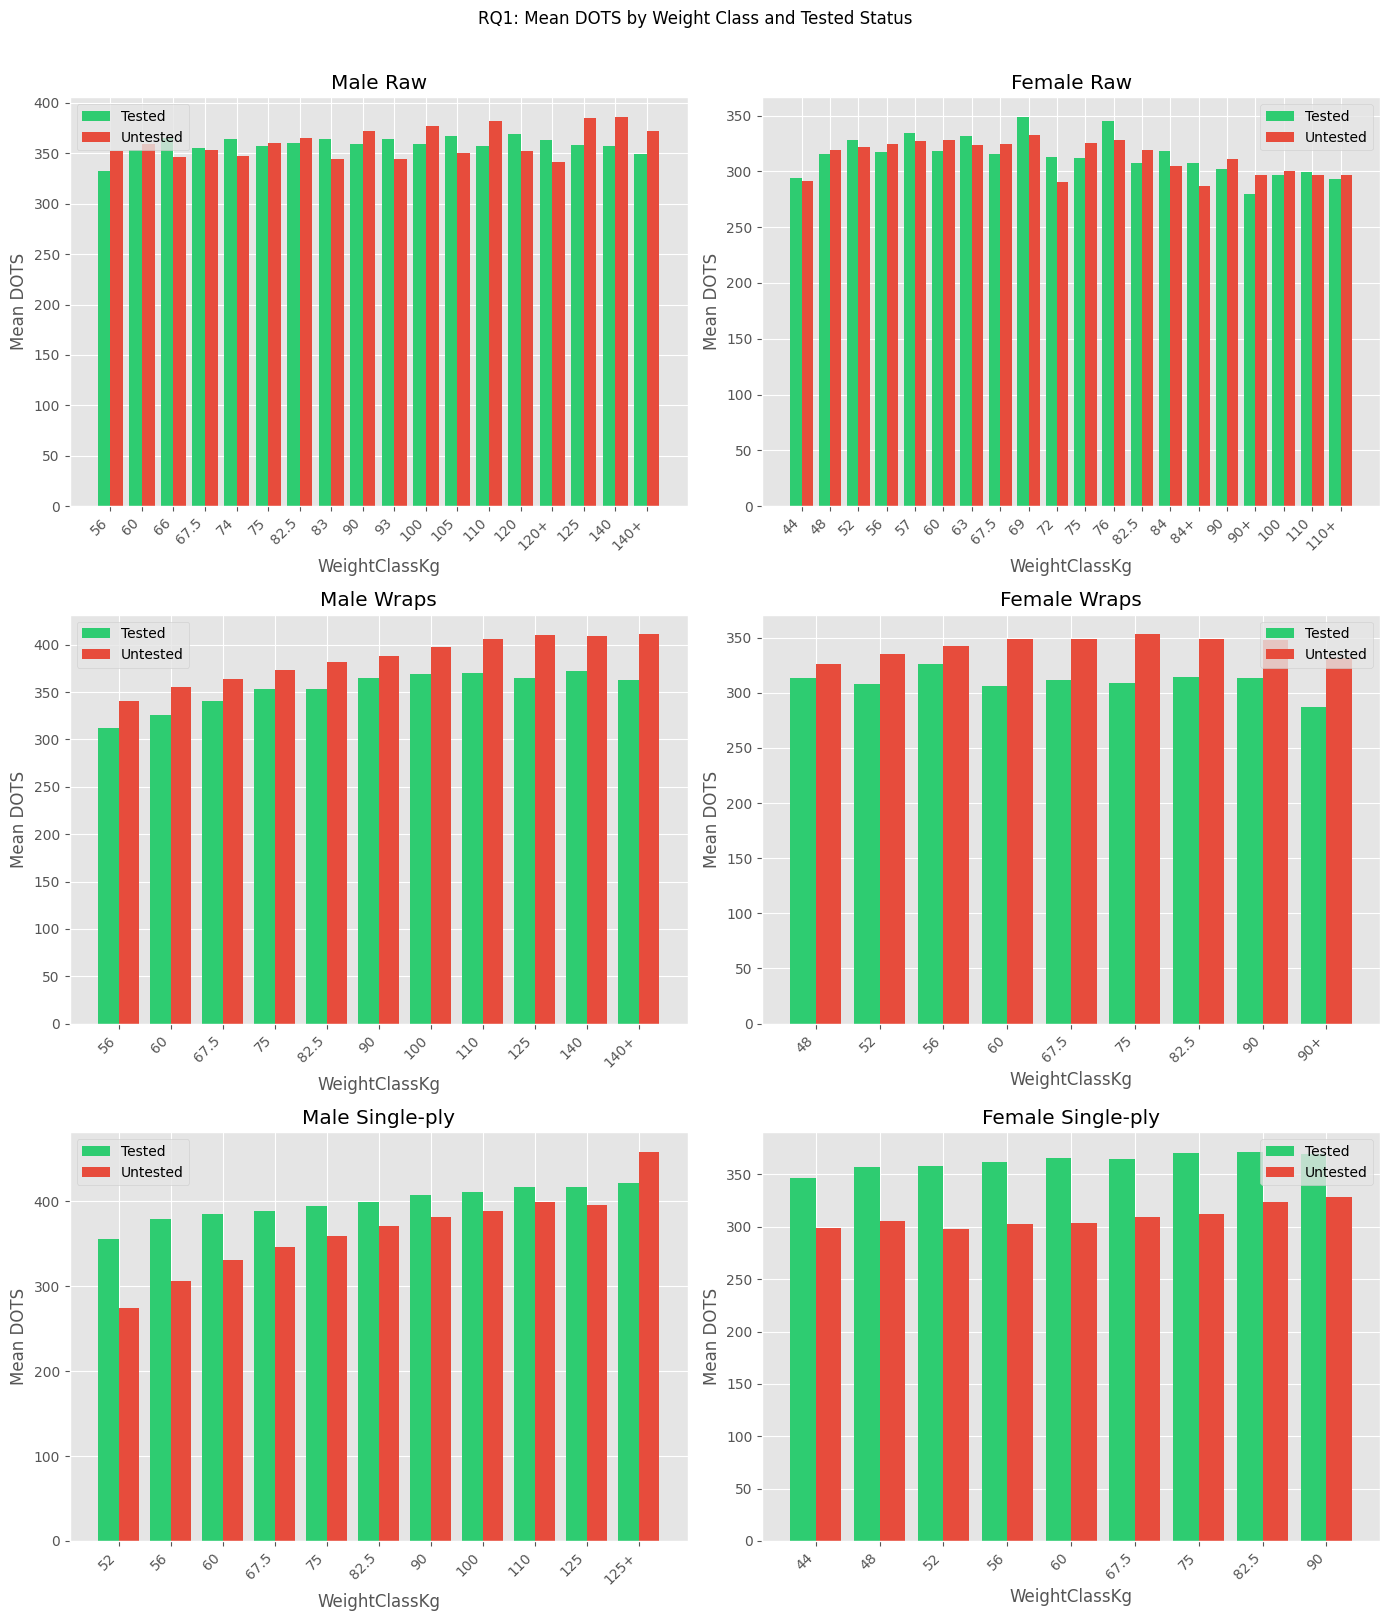

In [140]:
# =============================================================================
# RQ1 Mean DOTS by Weight Class (Bar Chart)
# Side-by-side bar chart comparing mean DOTS for tested vs. untested
# entries across weight classes, with separate panels for each
# Sex x Equipment combination (Raw, Wraps, Single-ply).
# =============================================================================

def weight_class_sort_key(wc_series):
    """Turn WeightClassKg into a numeric sort key.
    Strip the trailing '+' for the base number, then add 0.5 so that
    '125+' sorts after '125' instead of tying with it.
    """
    base = pd.to_numeric(
        wc_series.astype(str).str.replace("+", "", regex=False),
        errors="coerce"
    )
    is_plus = wc_series.astype(str).str.endswith("+")
    return base + is_plus * 0.5

summary = (
    rq1_supported_df
    .groupby(["Sex", "Equipment", "WeightClassKg", "is_tested"])
    .agg(mean_dots=("Dots", "mean"), n=("Dots", "size"))
    .reset_index()
)

equipment_order = ["Raw", "Wraps", "Single-ply"]

fig, axes = plt.subplots(len(equipment_order), 2, figsize=(14, 16))

for row_num, equip in enumerate(equipment_order):
    equip_df = summary[summary["Equipment"] == equip].copy()

    for col_num, sex in enumerate(["M", "F"]):
        ax = axes[row_num, col_num]
        sex_df = equip_df[equip_df["Sex"] == sex].copy()

        if len(sex_df) == 0:
            ax.set_title(f"{'Male' if sex == 'M' else 'Female'} {equip} (no data)")
            ax.set_xticks([])
            continue

        tested_df = sex_df[sex_df["is_tested"] == True].copy()
        untested_df = sex_df[sex_df["is_tested"] == False].copy()

        common_wcs = sorted(
            set(tested_df["WeightClassKg"]) & set(untested_df["WeightClassKg"])
        )
        tested_df = tested_df[tested_df["WeightClassKg"].isin(common_wcs)].copy()
        untested_df = untested_df[untested_df["WeightClassKg"].isin(common_wcs)].copy()

        tested_df["sort_key"] = weight_class_sort_key(tested_df["WeightClassKg"])
        untested_df["sort_key"] = weight_class_sort_key(untested_df["WeightClassKg"])

        tested_df = tested_df.sort_values("sort_key")
        untested_df = untested_df.sort_values("sort_key")

        x = np.arange(len(tested_df))

        ax.bar(x - 0.2, tested_df["mean_dots"], width=0.4, label="Tested", color="#2ecc71")
        ax.bar(x + 0.2, untested_df["mean_dots"], width=0.4, label="Untested", color="#e74c3c")
        ax.set_xticks(x)
        ax.set_xticklabels(tested_df["WeightClassKg"], rotation=45, ha="right")
        ax.set_xlabel("WeightClassKg")
        ax.set_ylabel("Mean DOTS")
        ax.set_title(f"{'Male' if sex == 'M' else 'Female'} {equip}")
        ax.legend()

plt.suptitle("RQ1: Mean DOTS by Weight Class and Tested Status", y=1.01)
plt.tight_layout()

# plt.savefig("figures/rq1_mean_dots_by_weightclass.svg", bbox_inches="tight")
plt.show()

**Supplementary Figure RQ1-S1.** Mean DOTS score by weight class and tested status, shown separately for each equipment type (Raw, Wraps, Single-ply) and sex (Male, Female). Each row is one equipment type; the left column shows male lifters and the right column shows female lifters. Green bars represent tested entries; red bars represent untested entries.

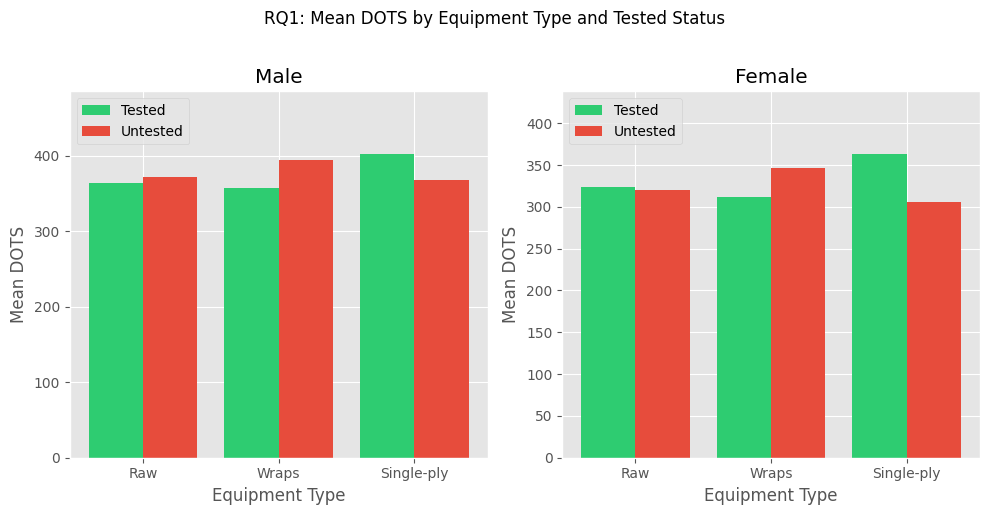

In [141]:
# =============================================================================
# RQ1 Mean DOTS by Equipment Type (Compact Report Chart)
# Side-by-side bar chart comparing mean DOTS for tested vs. untested
# entries across equipment types, with one panel per sex.
# This is a compact version of the weight-class chart above, intended
# where space is limited.
# =============================================================================

equip_summary = (
    rq1_supported_df
    .groupby(["Sex", "Equipment", "is_tested"])
    .agg(mean_dots=("Dots", "mean"))
    .reset_index()
)

equipment_order = ["Raw", "Wraps", "Single-ply"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for col_num, sex in enumerate(["M", "F"]):
    ax = axes[col_num]
    sex_df = equip_summary[equip_summary["Sex"] == sex].copy()

    tested_vals = []
    untested_vals = []
    for equip in equipment_order:
        t = sex_df[(sex_df["Equipment"] == equip) & (sex_df["is_tested"] == True)]
        u = sex_df[(sex_df["Equipment"] == equip) & (sex_df["is_tested"] == False)]
        tested_vals.append(t["mean_dots"].values[0] if len(t) > 0 else 0)
        untested_vals.append(u["mean_dots"].values[0] if len(u) > 0 else 0)

    x = np.arange(len(equipment_order))
    ax.bar(x - 0.2, tested_vals, width=0.4, label="Tested", color="#2ecc71")
    ax.bar(x + 0.2, untested_vals, width=0.4, label="Untested", color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(equipment_order)
    ax.set_xlabel("Equipment Type")
    ax.set_ylabel("Mean DOTS")
    ax.set_title(f"{'Male' if sex == 'M' else 'Female'}")

    # Add headroom so the legend does not overlap the bars
    y_lo, y_hi = ax.get_ylim()
    ax.set_ylim(y_lo, y_hi + (y_hi - y_lo) * 0.15)
    ax.legend(loc="upper left")

plt.suptitle("RQ1: Mean DOTS by Equipment Type and Tested Status", y=1.02)
plt.tight_layout()

# plt.savefig("figures/rq1_mean_dots_by_equipment.svg", bbox_inches="tight")
plt.show()

**Figure RQ1-1.** Overall mean DOTS by equipment type and tested status, shown separately for men (left) and women (right). Green bars represent tested entries; red bars represent untested entries.

### RQ1 Process Illustrations: Representative Subgroups

The tests above ran across all qualifying subgroups. The next eight figures zoom into two representative Male Raw subgroups to show what the process looks like on a single comparison. I picked both with a simple sample-size rule (the weight class with the most combined rows), not because they support or contradict the hypothesis.

- **Opposite-direction subgroup (Figures RQ1-2 through RQ1-5).** The largest Male Raw weight class overall, where tested athletes scored higher (the opposite direction from Ha).
- **Illustrative positive-gap subgroup (Figures RQ1-6 through RQ1-9).** The largest Male Raw weight class among subgroups with a positive DOTS gap and an uncorrected permutation p-value below 0.05. This label is only for choosing a stable example; the printed permutation-test interpretation still uses the Bonferroni-corrected threshold.

The first four figures use the opposite-direction subgroup. The next four use the illustrative positive-gap subgroup. For each subgroup I show four figures: a permutation null distribution and a bootstrap CI for both DOTS and TotalKg. The permutation plots overlay a KDE curve on the histogram to show the smooth shape of the null distribution. The bootstrap plots mark the observed gap, the 95% CI bounds, and zero.


Subgroup: Male / Raw / 93
Tested n = 12924, Untested n = 375
Observed gap (DOTS) = -19.59
Estimated permutation p-value = 1.0000
The estimated p-value is 1.0000, which is not less than the Bonferroni-corrected threshold of 0.000641.
We fail to reject the null hypothesis for this subgroup.


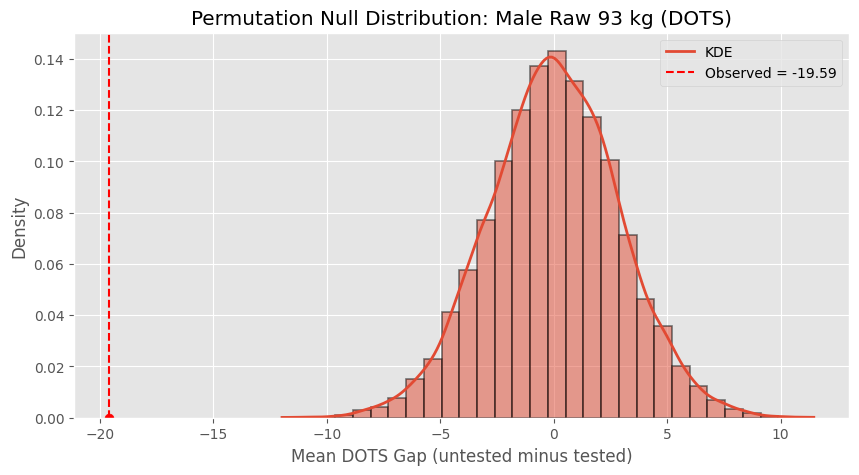

In [142]:
# =============================================================================
# RQ1 Permutation Null Distribution - DOTS (Representative Subgroup)
# Shuffle tested/untested labels to build the null distribution of
# the mean DOTS gap for the largest Male Raw subgroup, then plot the
# histogram with KDE overlay and the observed gap.
# =============================================================================

# Filter to Male Raw subgroups, sum tested + untested counts to get
# the total sample size for each weight class, sort descending, and
# take the weight class with the most data so the illustration is stable.
demo_male_raw = rq1_results[
    (rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")
].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed test statistic
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says untested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_dots, tested_dots])
n_untested = len(untested_dots)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc} kg (DOTS)")
plt.xlabel("Mean DOTS Gap (untested minus tested)")
plt.ylabel("Density")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_dots)}, Untested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < bonferroni_alpha:
    print(f"The estimated p-value is less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We fail to reject the null hypothesis for this subgroup.")


plt.show()


**Figure RQ1-2.** Permutation null distribution for the mean DOTS gap in the largest (opposite-direction) Male Raw 93 kg subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/untested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 93
Tested n = 12924, Untested n = 375
Observed gap (DOTS) = -19.59
95% CI: [-24.76, -14.52]
The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.


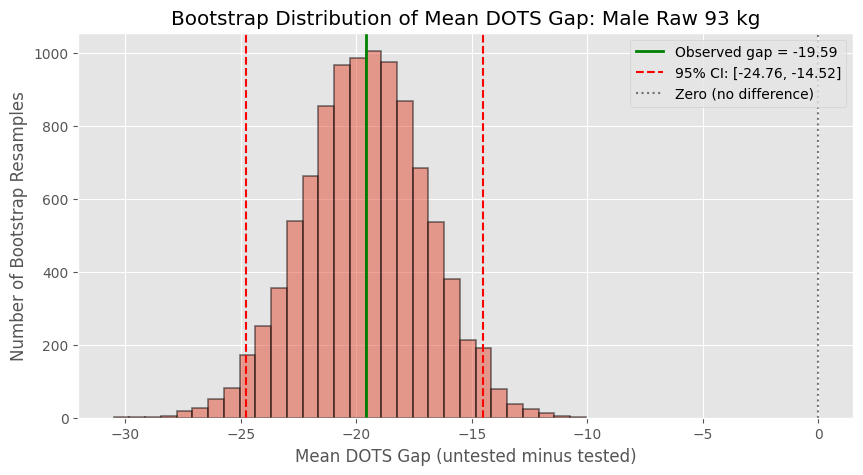

In [143]:
# =============================================================================
# RQ1 Bootstrap CI Illustration -- DOTS (Representative Subgroup)
# Bootstrap the mean DOTS gap for the largest Male Raw subgroup and
# plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Filter to Male Raw subgroups, sum tested + untested counts to get
# the total sample size for each weight class, sort descending, and
# take the weight class with the most data so the illustration is stable.
demo_male_raw = rq1_results[(rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed gap
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_dots, size=len(tested_dots), replace=True)
    boot_untested = np.random.choice(untested_dots, size=len(untested_dots), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean DOTS Gap: Male Raw {demo_wc} kg")
plt.xlabel("Mean DOTS Gap (untested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_dots)}, Untested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0:
    print(f"The 95% CI is entirely above zero, meaning untested lifters scored higher in this subgroup -- consistent with Ha.")
elif ci_high < 0:
    print(f"The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.")
else:
    print(f"The 95% CI includes zero, meaning the gap could be positive or negative -- not enough evidence to say which group scored higher in this subgroup.")


plt.show()

**Figure RQ1-3.** Bootstrap distribution of the mean DOTS gap (untested minus tested) for the largest (opposite-direction) Male Raw 93 kg subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

Subgroup: Male / Raw / 93
Tested n = 12924, Untested n = 375
Observed gap (TotalKg) = -33.99
Estimated permutation p-value = 1.0000
The estimated p-value is 1.0000, which is not less than the Bonferroni-corrected threshold of 0.000641.
We fail to reject the null hypothesis for this subgroup.


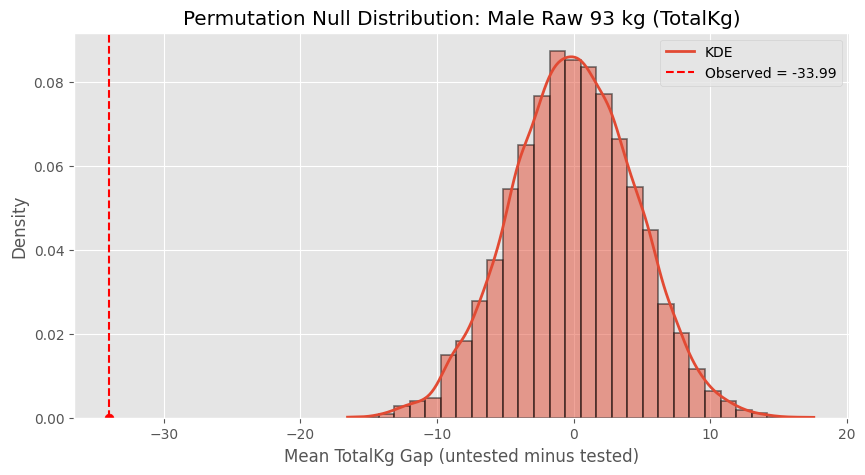

In [144]:
# =============================================================================
# RQ1 Permutation Null Distribution - TotalKg (Representative Subgroup)
# Shuffle tested/untested labels to build the null distribution of
# the mean TotalKg gap for the same representative Male Raw subgroup,
# then plot the histogram with KDE overlay and the observed gap.
# =============================================================================

# Same representative subgroup as the DOTS illustration (Male Raw weight class with the most combined rows)
demo_male_raw = rq1_results[(rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed test statistic (untested minus tested)
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says untested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_total, tested_total])
n_untested = len(untested_total)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc} kg (TotalKg)")
plt.xlabel("Mean TotalKg Gap (untested minus tested)")
plt.ylabel("Density")
plt.legend()


print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_total)}, Untested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < bonferroni_alpha:
    print(f"The estimated p-value is less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We fail to reject the null hypothesis for this subgroup.")


plt.show()


**Figure RQ1-4.** Permutation null distribution for the mean TotalKg gap in the largest (opposite-direction) Male Raw 93 kg subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/untested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 93
Tested n = 12924, Untested n = 375
Observed gap (TotalKg) = -33.99
95% CI: [-42.00, -25.76]
The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.


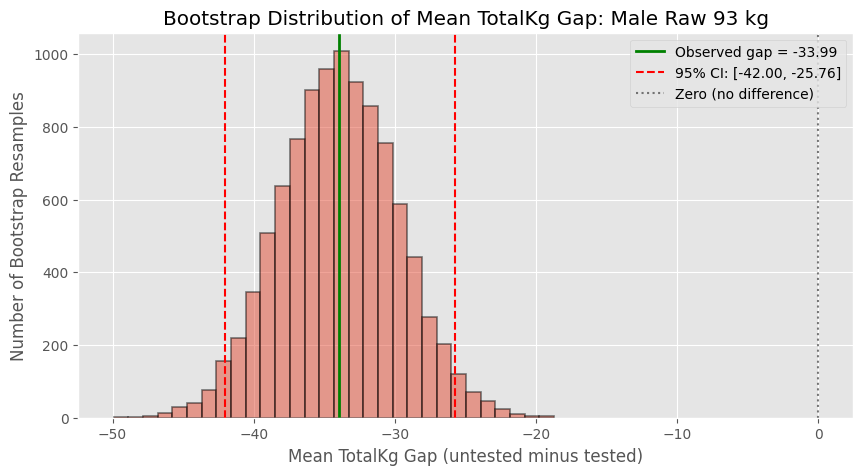

In [145]:
# =============================================================================
# RQ1 Bootstrap CI Illustration -- TotalKg (Representative Subgroup)
# Bootstrap the mean TotalKg gap for the same representative Male Raw
# subgroup and plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Same representative subgroup as the DOTS illustration
# (Male Raw weight class with the most combined rows)
demo_male_raw = rq1_results[(rq1_results["Sex"] == "M") & (rq1_results["Equipment"] == "Raw")].copy()
demo_male_raw["n_total"] = demo_male_raw["n_tested"] + demo_male_raw["n_untested"]
demo_row = demo_male_raw.sort_values("n_total", ascending=False).iloc[0]
demo_wc = demo_row["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed gap
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_total, size=len(tested_total), replace=True)
    boot_untested = np.random.choice(untested_total, size=len(untested_total), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Plot the bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean TotalKg Gap: Male Raw {demo_wc} kg")
plt.xlabel("Mean TotalKg Gap (untested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc}")
print(f"Tested n = {len(tested_total)}, Untested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

if ci_low > 0:
    print(f"The 95% CI is entirely above zero, meaning untested lifters scored higher in this subgroup -- consistent with Ha.")
elif ci_high < 0:
    print(f"The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup -- the opposite of what Ha predicts.")
else:
    print(f"The 95% CI includes zero, meaning the gap could be positive or negative -- not enough evidence to say which group scored higher in this subgroup.")


plt.show()

**Figure RQ1-5.** Bootstrap distribution of the mean TotalKg gap (untested minus tested) for the largest (opposite-direction) Male Raw 93 kg subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

Subgroup: Male / Raw / 100
Tested n = 2531, Untested n = 5388
Observed gap (DOTS) = 18.17
Estimated permutation p-value = 0.0000
The estimated p-value is less than the Bonferroni-corrected threshold of 0.000641.
We reject the null hypothesis for this subgroup.


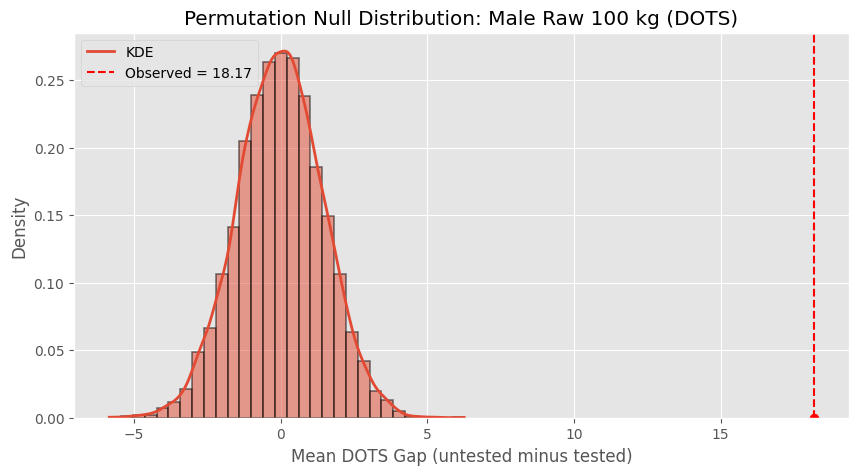

In [146]:
# =============================================================================
# RQ1 Permutation Null Distribution - DOTS (Illustrative Positive-Gap Subgroup)
# Shuffle tested/untested labels to build the null distribution of
# the mean DOTS gap for the illustrative Male Raw subgroup, then plot
# the histogram with KDE overlay and the observed gap.
# =============================================================================

# Filter to Male Raw subgroups where the DOTS gap is positive and the
# uncorrected permutation p-value is below 0.05. Then pick the weight
# class with the most combined rows so the illustration is stable.
# This only chooses a demo subgroup. The final interpretation still
# uses the Bonferroni-corrected threshold.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed test statistic
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says untested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_dots, tested_dots])
n_untested = len(untested_dots)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc_sig} kg (DOTS)")
plt.xlabel("Mean DOTS Gap (untested minus tested)")
plt.ylabel("Density")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_dots)}, Untested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < bonferroni_alpha:
    print(f"The estimated p-value is less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We fail to reject the null hypothesis for this subgroup.")


plt.show()


**Figure RQ1-6.** Permutation null distribution for the mean DOTS gap in the illustrative positive-gap Male Raw subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/untested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 100
Tested n = 2531, Untested n = 5388
Observed gap (DOTS) = 18.17
95% CI: [15.42, 20.96]
This bootstrap interval is a descriptive summary, so the Bonferroni correction does not change the CI itself.
The 95% CI is entirely above zero, meaning untested lifters scored higher in this subgroup, which lines up with Ha.


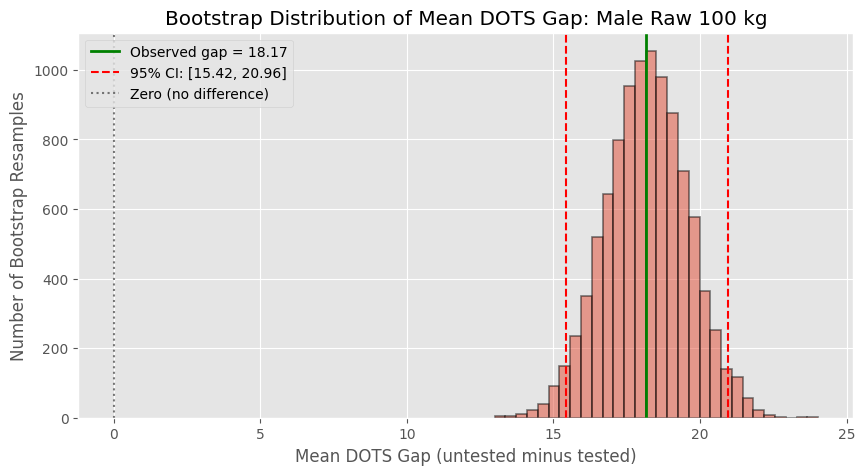

In [147]:
# =============================================================================
# RQ1 Bootstrap CI Illustration - DOTS (Illustrative Positive-Gap Subgroup)
# Bootstrap the mean DOTS gap for the illustrative Male Raw subgroup
# and plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Filter to Male Raw subgroups where the DOTS gap is positive and the
# uncorrected permutation p-value is below 0.05. Then pick the weight
# class with the most combined rows so the illustration is stable.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_dots = demo_df[demo_df["is_tested"] == True]["Dots"].dropna().values
untested_dots = demo_df[demo_df["is_tested"] == False]["Dots"].dropna().values

# Observed gap
observed_gap = np.mean(untested_dots) - np.mean(tested_dots)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_dots, size=len(tested_dots), replace=True)
    boot_untested = np.random.choice(untested_dots, size=len(untested_dots), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean DOTS Gap: Male Raw {demo_wc_sig} kg")
plt.xlabel("Mean DOTS Gap (untested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_dots)}, Untested n = {len(untested_dots)}")
print(f"Observed gap (DOTS) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print("This bootstrap interval is a descriptive summary, so the Bonferroni correction does not change the CI itself.")

if ci_low > 0:
    print("The 95% CI is entirely above zero, meaning untested lifters scored higher in this subgroup, which lines up with Ha.")
elif ci_high < 0:
    print("The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup, which is the opposite of Ha.")
else:
    print("The 95% CI includes zero, meaning the gap could be positive or negative, so the interval does not point clearly in one direction.")


plt.show()


**Figure RQ1-7.** Bootstrap distribution of the mean DOTS gap (untested minus tested) for the illustrative positive-gap Male Raw subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

Subgroup: Male / Raw / 100
Tested n = 2531, Untested n = 5388
Observed gap (TotalKg) = 29.29
Estimated permutation p-value = 0.0000
The estimated p-value is less than the Bonferroni-corrected threshold of 0.000641.
We reject the null hypothesis for this subgroup.


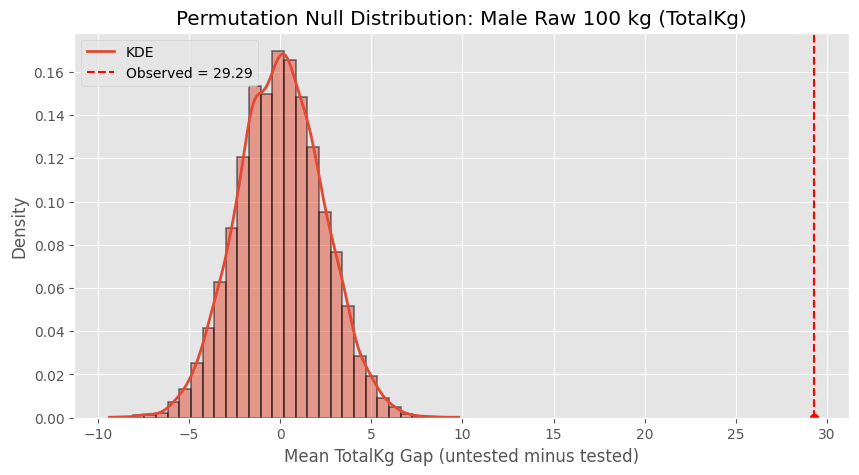

In [148]:
# =============================================================================
# RQ1 Permutation Null Distribution - TotalKg (Illustrative Positive-Gap Subgroup)
# Shuffle tested/untested labels to build the null distribution of
# the mean TotalKg gap for the illustrative Male Raw subgroup, then plot
# the histogram with KDE overlay and the observed gap.
# =============================================================================

# Same illustrative subgroup as the DOTS illustration
# Filter to Male Raw subgroups where the DOTS gap is positive and the
# uncorrected permutation p-value is below 0.05. Then pick the weight
# class with the most combined rows so the illustration is stable.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed test statistic (untested minus tested)
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Permutation test: shuffle-split
# Concatenate the two samples, shuffle the combined data, split into
# two new groups, and recompute the gap each time. One-sided test:
# Ha says untested is higher, so count how often the shuffled gap is at least as large as the observed gap.
all_data = np.concatenate([untested_total, tested_total])
n_untested = len(untested_total)

perm_gaps = []
for i in range(N_PERMUTATIONS):
    shuffled = all_data.copy()
    np.random.shuffle(shuffled)
    perm_gap = np.mean(shuffled[:n_untested]) - np.mean(shuffled[n_untested:])
    perm_gaps.append(perm_gap)

perm_gaps = np.array(perm_gaps)
p_value = np.mean(perm_gaps >= observed_gap)

# KDE of the null distribution
kde_null = gaussian_kde(perm_gaps)
x_values = np.linspace(perm_gaps.min(), perm_gaps.max(), 200)
y_values = kde_null.evaluate(x_values)

# Plot the null distribution (histogram + KDE overlay)
plt.figure(figsize=(10, 5))
plt.hist(perm_gaps, bins=30, density=True, alpha=0.5, edgecolor="black", linewidth=1.2)
plt.plot(x_values, y_values, color="C0", linewidth=2, label="KDE")
plt.axvline(observed_gap, linestyle="--", color="Red", label=f"Observed = {observed_gap:.2f}")
plt.scatter(observed_gap, 0, color="Red", s=40)

plt.title(f"Permutation Null Distribution: Male Raw {demo_wc_sig} kg (TotalKg)")
plt.xlabel("Mean TotalKg Gap (untested minus tested)")
plt.ylabel("Density")
plt.legend()


print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_total)}, Untested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"Estimated permutation p-value = {p_value:.4f}")

if p_value < bonferroni_alpha:
    print(f"The estimated p-value is less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We reject the null hypothesis for this subgroup.")
else:
    print(f"The estimated p-value is {p_value:.4f}, which is not less than the Bonferroni-corrected threshold of {bonferroni_alpha:.6f}.")
    print("We fail to reject the null hypothesis for this subgroup.")


plt.show()


**Figure RQ1-8.** Permutation null distribution for the mean TotalKg gap in the illustrative positive-gap Male Raw subgroup. The histogram shows the distribution of gaps produced by randomly shuffling tested/untested labels. The dashed red line and dot mark the observed gap; a KDE curve is overlaid to show the smooth shape of the null distribution.

Subgroup: Male / Raw / 100
Tested n = 2531, Untested n = 5388
Observed gap (TotalKg) = 29.29
95% CI: [24.90, 33.73]
This bootstrap interval is a descriptive summary, so the Bonferroni correction does not change the CI itself.
The 95% CI is entirely above zero, meaning untested lifters scored higher in this subgroup, which lines up with Ha.


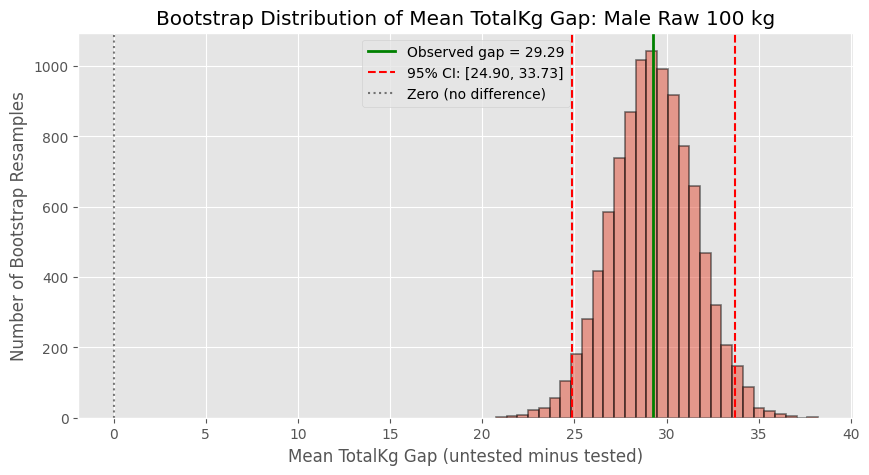

In [149]:
# =============================================================================
# RQ1 Bootstrap CI Illustration - TotalKg (Illustrative Positive-Gap Subgroup)
# Bootstrap the mean TotalKg gap for the illustrative Male Raw subgroup
# and plot the resampled distribution with the observed gap and 95% CI.
# =============================================================================

# Same illustrative subgroup as the DOTS illustration
# Filter to Male Raw subgroups where the DOTS gap is positive and the
# uncorrected permutation p-value is below 0.05. Then pick the weight
# class with the most combined rows so the illustration is stable.
demo_sig = rq1_results[
    (rq1_results["Sex"] == "M") &
    (rq1_results["Equipment"] == "Raw") &
    (rq1_results["gap_dots"] > 0) &
    (rq1_results["gap_dots_perm_p"] < ALPHA)
].copy()
demo_sig["n_total"] = demo_sig["n_tested"] + demo_sig["n_untested"]
demo_row_sig = demo_sig.sort_values("n_total", ascending=False).iloc[0]
demo_wc_sig = demo_row_sig["WeightClassKg"]

# Filter to the subgroup
demo_df = rq1_supported_df[
    (rq1_supported_df["Sex"] == "M") &
    (rq1_supported_df["Equipment"] == "Raw") &
    (rq1_supported_df["WeightClassKg"] == demo_wc_sig)
].copy()

tested_total = demo_df[demo_df["is_tested"] == True]["TotalKg"].dropna().values
untested_total = demo_df[demo_df["is_tested"] == False]["TotalKg"].dropna().values

# Observed gap
observed_gap = np.mean(untested_total) - np.mean(tested_total)

# Bootstrap the gap
boot_gaps = []
for i in range(N_BOOTSTRAP):
    boot_tested = np.random.choice(tested_total, size=len(tested_total), replace=True)
    boot_untested = np.random.choice(untested_total, size=len(untested_total), replace=True)
    boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

boot_gaps = np.array(boot_gaps)

# 95% confidence interval
ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])

# Plot the bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(boot_gaps, bins=30, edgecolor="black", linewidth=1.2, alpha=0.5)
plt.axvline(observed_gap, color="green", linewidth=2, label=f"Observed gap = {observed_gap:.2f}")
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.axvline(ci_high, color="red", linestyle="--")
plt.axvline(0, color="black", linestyle=":", alpha=0.5, label="Zero (no difference)")

plt.title(f"Bootstrap Distribution of Mean TotalKg Gap: Male Raw {demo_wc_sig} kg")
plt.xlabel("Mean TotalKg Gap (untested minus tested)")
plt.ylabel("Number of Bootstrap Resamples")
plt.legend()

print(f"Subgroup: Male / Raw / {demo_wc_sig}")
print(f"Tested n = {len(tested_total)}, Untested n = {len(untested_total)}")
print(f"Observed gap (TotalKg) = {observed_gap:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print("This bootstrap interval is a descriptive summary, so the Bonferroni correction does not change the CI itself.")

if ci_low > 0:
    print("The 95% CI is entirely above zero, meaning untested lifters scored higher in this subgroup, which lines up with Ha.")
elif ci_high < 0:
    print("The 95% CI is entirely below zero, meaning tested lifters scored higher in this subgroup, which is the opposite of Ha.")
else:
    print("The 95% CI includes zero, meaning the gap could be positive or negative, so the interval does not point clearly in one direction.")


plt.show()


**Figure RQ1-9.** Bootstrap distribution of the mean TotalKg gap (untested minus tested) for the illustrative positive-gap Male Raw subgroup. The green line marks the observed gap, the dashed red lines mark the 95% bootstrap confidence interval, and the dotted black line marks zero (no difference).

### RQ1 Conclusion  

**The data does not support a simple "untested entries always score higher" conclusion.**  

Across the 78 subgroups with enough data to test, the Bonferroni-corrected result is the main formal finding: `29` subgroups were significant by both the one-sided permutation test and the one-sided Welch test in the untested-higher direction. The corrected threshold was `alpha / m = 0.05 / 78 = 0.000641`. The corrected count was identical for `TotalKg` and `Dots`, which is what we expect when bodyweight varies little inside a single weight class and DOTS is therefore close to a rescaled version of TotalKg.

The bootstrap CI classification still splits three ways: 34 subgroups had intervals entirely above zero, 32 had intervals entirely below zero, and 12 included zero. Those CI tallies are descriptive summaries of direction and size, so they do not change under the Bonferroni correction.

The equipment breakdown explains why the overall result looks mixed:  
- Wraps leaned strongly toward higher untested scores.
- Raw results are mixed.
- Single-ply mostly went the other way in the sample. 
- Multi-ply is absent because none of its subgroup pairs met the minimum-count rule.  

Among the Bonferroni-corrected subgroups, the `TotalKg` gaps ran from about `8.1` kg to `85.1` kg, with a median near `38.0` kg. On the other side, the 32 subgroups with bootstrap intervals entirely below zero should be read as matchups where the sample pattern went in the opposite direction, not as separate formal proof of a tested-higher hypothesis, because that reverse direction was not the one formally tested here.  

Even after the Bonferroni correction, the big picture is the same: the results vary by equipment type, and no single subgroup tells the whole story.  


## RQ2: Testing, Testing... Anyone Still Here? (Trend Analysis)

**Is tested status associated with DOTS-score bin, separately by sex?**

RQ2 uses one representative row per `Name x Sex x is_tested`, where repeated same-status entries are collapsed to a mean `Dots` value first. 

**Hypotheses:**  

- **H0:** DOTS-score bin and tested status are independent within each sex.
- **Ha:** DOTS-score bin and tested status are associated within each sex.

**Approach:**  

A chi-squared test of independence evaluates whether the tested-entry share differs across DOTS-score bins within each sex. The accompanying line chart illustrates the pattern the chi-squared test formally evaluates. Five equal-width bins were chosen as the most granular split that still keeps all expected cell frequencies above 5.

In [150]:
# =============================================================================
# RQ2 Bin Diagnostics and Chi-Squared Tests
# For each sex, bin the representative Dots values into 5 equal-width
# bins, build a contingency table crossing bin by tested status, and
# run a chi-squared test of independence.
# =============================================================================
for sex in ["M", "F"]:
    sex_df = rq2_analysis_df[rq2_analysis_df["Sex"] == sex].copy()

    # Split the Dots range into 5 equal-width bins for this sex.
    bin_edges = np.linspace(
        sex_df["Dots"].min(),
        sex_df["Dots"].max(),
        N_RQ2_BINS + 1
    )
    sex_df["dots_bin"] = pd.cut(
        sex_df["Dots"],
        bins=bin_edges,
        include_lowest=True
    )

    # Count rows in each (dots_bin, is_tested) group, then pivot so
    # each tested status becomes its own column. fill_value=0 means
    # any bin with no rows for a status gets a zero instead of NaN.
    contingency = (
        sex_df.groupby(["dots_bin", "is_tested"])
        .size()
        .unstack(fill_value=0)
    )

    # If a column is missing (e.g., no tested or no untested rows in a bin),
    # add it with zeros so both columns always exist.
    if True not in contingency.columns:
        contingency[True] = 0
    if False not in contingency.columns:
        contingency[False] = 0

    # Drop any bins that ended up completely empty (zero rows total).
    row_totals = contingency.sum(axis=1)
    contingency = contingency[row_totals > 0]

    # Run the chi-squared test of independence.
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    # Check whether every expected count is at least 5 (a requirement
    # for the chi-squared approximation to be valid).
    expected_ok = (expected >= 5).all()
    min_expected = expected.min()

    # Compute the tested-entry share (%) in each DOTS bin.
    bin_totals = contingency.sum(axis=1)
    bin_tested = contingency[True]
    pct_tested = 100 * bin_tested / bin_totals

    sex_label = {"M": "Men", "F": "Women"}[sex]

    print("")
    
    print(f"Contingency table for {sex_label}:")
    display(contingency)

    print(f"Tested-entry share by DOTS bin for {sex_label} (%):")
    display(pct_tested.to_frame("% Tested"))

    print(f"\nChi-square test of independence for {sex_label}:") 
    print(f"\nchi2 = {chi2:.2f}, p = {p_val:.6f}, df = {dof}")
    print(f"All expected counts >= 5: {expected_ok}")
    print(f"Minimum expected count: {min_expected:.2f}")

    print("")

    if p_val < ALPHA:
        print(f"p = {p_val:.6f} is less than {ALPHA}, so we reject H0.")
        print("")
        print(f"Testing rates are not uniform across strength levels.")
        print(f"We conclude that DOTS-score bin and tested status are associated for {sex_label}.")
    else:
        print(f"p = {p_val:.6f} is not less than {ALPHA}, so we fail to reject H0.")
        print("")
        print(f"Testing rates appear uniform across strength levels")
        print(f"We conclude that there is no significant association between DOTS-score bin and tested status for {sex_label}.")




Contingency table for Men:


is_tested,False,True
dots_bin,,
"(30.569, 168.729]",202,283
"(168.729, 306.888]",10497,14024
"(306.888, 445.048]",47083,68725
"(445.048, 583.207]",8809,14093
"(583.207, 721.366]",144,61


Tested-entry share by DOTS bin for Men (%):


,% Tested
dots_bin,
"(30.569, 168.729]",58.3505
"(168.729, 306.888]",57.1918
"(306.888, 445.048]",59.3439
"(445.048, 583.207]",61.5361
"(583.207, 721.366]",29.7561



Chi-square test of independence for Men:

chi2 = 166.99, p = 0.000000, df = 4
All expected counts >= 5: True
Minimum expected count: 83.46

p = 0.000000 is less than 0.05, so we reject H0.

Testing rates are not uniform across strength levels.
We conclude that DOTS-score bin and tested status are associated for Men.

Contingency table for Women:


is_tested,False,True
dots_bin,,
"(68.81899999999999, 205.988]",680,1447
"(205.988, 343.156]",13465,23575
"(343.156, 480.324]",5775,15340
"(480.324, 617.492]",429,922
"(617.492, 754.66]",17,7


Tested-entry share by DOTS bin for Women (%):


,% Tested
dots_bin,
"(68.81899999999999, 205.988]",68.0301
"(205.988, 343.156]",63.6474
"(343.156, 480.324]",72.6498
"(480.324, 617.492]",68.2457
"(617.492, 754.66]",29.1667



Chi-square test of independence for Women:

chi2 = 510.37, p = 0.000000, df = 4
All expected counts >= 5: True
Minimum expected count: 7.93

p = 0.000000 is less than 0.05, so we reject H0.

Testing rates are not uniform across strength levels.
We conclude that DOTS-score bin and tested status are associated for Women.


The chi-squared test rejects `H0` for both sexes: men have chi2 = 166.99 with p < 0.001, and women have chi2 = 510.37 with p < 0.001. All expected counts are above 5 (minimum 83.46 for men, 7.93 for women), so the chi-squared approximation is on solid ground. Using one representative row per lifter-status combination also helps reduce dependence from repeated entries.

These test results come from the contingency-table counts, not from the percentages shown in the next figure. Figure RQ2-1 re-expresses the same grouped data as tested-entry share percentages so the pattern is easier to see, but the chart hides the bin sample sizes. That matters most at the edges, especially for women, where the highest DOTS bin has only 24 representative rows total (17 untested, 7 tested), so that top-bin percentage is more of a clue than a precise estimate.

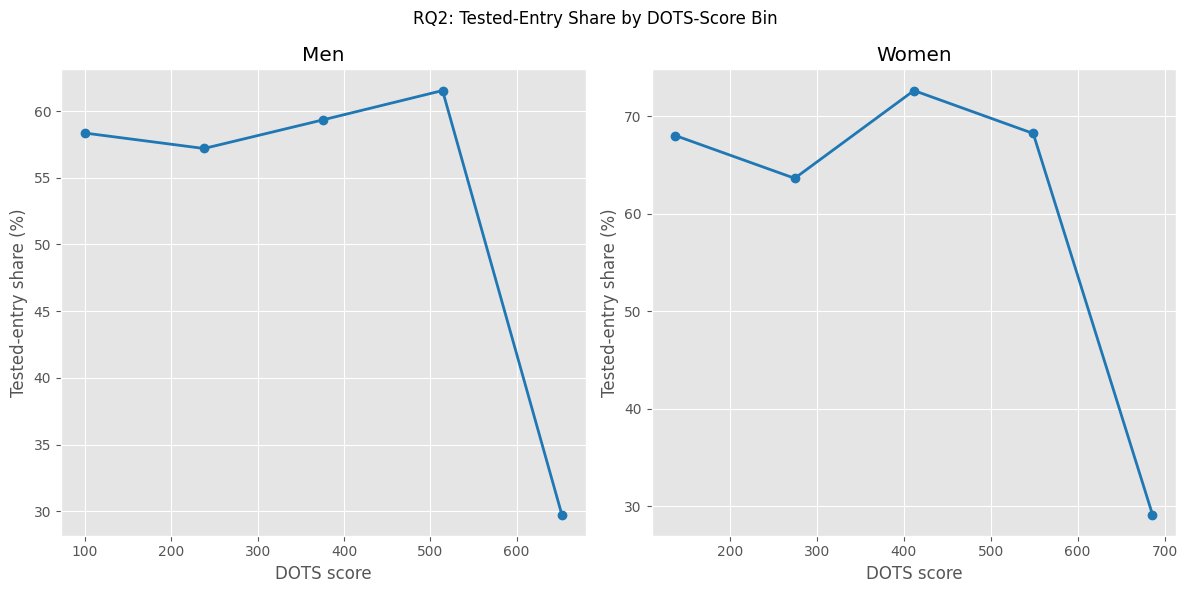

In [151]:
# =============================================================================
# RQ2 Tested-Entry Share by DOTS-Score Bin (Line Chart)
# Plot the tested-entry share (%) across DOTS bins for men and women
# in side-by-side panels so the trend is easy to see.
# =============================================================================
plt.figure(figsize=(12, 6))

for panel_num, sex in enumerate(["M", "F"], start=1):
    sex_df = rq2_analysis_df[rq2_analysis_df["Sex"] == sex].copy()

    # Same 5 equal-width DOTS bins as the test cell above.
    bin_edges = np.linspace(
        sex_df["Dots"].min(),
        sex_df["Dots"].max(),
        N_RQ2_BINS + 1
    )
    sex_df["dots_bin"] = pd.cut(
        sex_df["Dots"],
        bins=bin_edges,
        include_lowest=True
    )

    # Count rows in each (dots_bin, is_tested) group, then pivot so
    # each tested status becomes its own column.
    contingency = (
        sex_df.groupby(["dots_bin", "is_tested"])
        .size()
        .unstack(fill_value=0)
    )
    # If a column is missing, add it with zeros so both columns always exist.
    if True not in contingency.columns:
        contingency[True] = 0
    if False not in contingency.columns:
        contingency[False] = 0
    row_totals = contingency.sum(axis=1)
    contingency = contingency[row_totals > 0]

    # Use the center of each bin as the x-axis position.
    midpoints = []
    for interval in contingency.index:
        midpoints.append((interval.left + interval.right) / 2)

    # Tested-entry share (%) in each bin.
    bin_totals = contingency.sum(axis=1)
    bin_tested = contingency[True]
    pct_tested = 100 * bin_tested / bin_totals

    # One panel per sex.
    plt.subplot(1, 2, panel_num)
    plt.plot(midpoints, pct_tested.values, marker="o", linewidth=2, color="#1f77b4")
    plt.xlabel("DOTS score")
    plt.ylabel("Tested-entry share (%)")
    plt.title("Men" if sex == "M" else "Women")

plt.suptitle("RQ2: Tested-Entry Share by DOTS-Score Bin")
plt.tight_layout()

# plt.savefig("figures/rq2_tested_share_by_dots_bin.svg", bbox_inches="tight")
plt.show()

**Figure RQ2-1.** Tested-entry share (%) by DOTS-score bin, shown separately for men (left) and women (right). Each point represents one of five equal-width DOTS bins. The y-axis shows what percentage of representative rows in that bin came from tested competition entries.


### RQ2 Conclusion

**The share of tested entries is not the same across all DOTS bins, for either men or women.**

The chi-squared test of independence rejected H0 for both men (chi2 = 166.99, p < 0.001, df = 4) and women (chi2 = 510.37, p < 0.001, df = 4). The percentage of tested and untested entries shifts depending on how high the DOTS score is, and that shift is too large to be caused by random chance. All expected counts came in above 5 for both sexes, so the chi-squared approximation is on solid ground. The chi-squared test evaluates the full contingency table, not any single bin by itself.

Looking at the trend in Figure RQ2-1:
- For men, the tested-entry share hovers in a fairly narrow band (~57-62%) across the first four bins, then drops sharply to about 30% in the highest-DOTS bin.
- For women, the tested-entry share varies more across the first four bins (~64-73%) but shows a similar sharp drop to about 29% in the highest-DOTS bin.
- In both cases, the top-performing bin is the only one where untested entries outnumber tested entries. That pattern is consistent with the idea that the very highest DOTS scores show up disproportionately in untested competition contexts.

For women especially, the highest DOTS bin contains only 24 representative rows total (17 untested, 7 tested), so that top-bin percentage is useful as a clue but not a precise estimate.

## RQ3: Age Is Just a Number... Or Is It? (Age Pattern Comparison)

**Among representative lifter-status rows with known age / assigned age bin, do untested rows tend to show higher mean `TotalKg` across age bins, and how does that gap look at different ages?**

RQ3 uses one representative row per `Name x Sex x age_bin x is_tested` among rows with known age / assigned age bin, where repeated same-status entries are collapsed to a mean `TotalKg` value first. OpenPowerlifting records approximate ages like `23.5` when the exact birthday is unknown; boundary values like these are kept in the lower bin (so `23.5` falls in `18-23`) for a consistent, reproducible grouping rule.

**Approach:**

First, a KDE overlay plot compares the representative-row `TotalKg` distributions for tested and untested groups in two representative age bins, giving a visual sense of how much the two groups overlap. Then a bootstrap interval (10,000 resamples, percentile method) summarizes the untested-minus-tested gap in mean representative-row `TotalKg` within each age bin and sex. Bootstrap intervals were used here because they do not assume the data follows any particular shape, and they still work when the groups being compared have different sizes or different amounts of spread.

Because the question is directional, the main interval-based check is the one-sided 95% lower bootstrap bound. When that lower bound is above zero, the data support higher mean representative-row `TotalKg` for untested rows in that bin. When the lower bound is at or below zero, the data do not give clear interval-based support for that direction. The accompanying line chart shows the age-bin patterns those bootstrap bounds summarize.


In [152]:
# =============================================================================
# RQ3 Summary Table
# For each Sex x age_bin x is_tested group, compute the count, mean
# representative-row TotalKg, and standard deviation so the tested and
# untested sides
# can be compared at a glance.
# =============================================================================
age_summary = (
    rq3_supported_df
    .groupby(["Sex", "age_bin", "is_tested"])
    .agg({"TotalKg": ["size", "mean", "std"]})
    .reset_index()
)

display(age_summary.sort_values(["Sex", "age_bin", "is_tested"]))


Sex age_bin is_tested TotalKg                  
                            size     mean      std
0    F   18-23     False    1968 315.9559  69.9667
1    F   18-23      True   11045 317.1978  79.7194
2    F   24-30     False    7534 318.3481  72.9088
3    F   24-30      True   14265 326.0673  77.0700
4    F   31-40     False    4904 326.6819  82.8560
5    F   31-40      True    8508 324.9050  78.5166
6    F   41-50     False    1048 339.5328  93.9541
7    F   41-50      True    2170 319.1038  77.1214
8    F   51-60     False     289 313.6105  95.1486
9    F   51-60      True     662 287.9813  66.5011
10   F     61+     False      84 264.5077  78.0779
11   F     61+      True     181 250.1724  65.0282
12   M   18-23     False    6497 582.3539 124.7566
13   M   18-23      True   29890 564.7160 119.3762
14   M   24-30     False   18599 607.9908 128.8282
15   M   24-30      True   32031 597.2655 120.6896
16   M   31-40     False   11091 628.7909 136.0901
17   M   31-40      True   17140 605.0551 126.1582
18   M   41-50     False    1903 627.6857 132.8051
19   M   41-50      True    4009 584.1671 125.5581
20   M   51-60     False     510 552.5706 126.4462
21   M   51-60      True    1367 512.2113 114.9997
22   M     61+     False     147 439.8328 117.3554
23   M     61+      True     507 412.4606 103.3724

The summary table above shows the average representative-row `TotalKg` and its spread for each group.

RQ3 uses only representative rows with known age / assigned age bin, which is why this section has fewer rows than RQ1 and RQ2. The 28.7% missing age rate from the base setup means the RQ3 sample is a subset of the cleaned data rather than the full cleaned dataset. The oldest bins, especially 61+, are much smaller, so their bootstrap ranges will be wider and their results less precise than the larger bins. The table above is useful for checking group means and spread, but the bootstrap intervals in a later cell are what determine which gaps still hold up once sampling variability is taken into account.

Before interpreting the bootstrap interval results, I wanted to look at the overall shape of the representative-row `TotalKg` distributions in two age bins, 24-30 and 41-50. I chose 24-30 because it has the most representative rows, and 41-50 because it is a middle-age bin with moderate counts on both sides. Together they show what the overlap looks like in a very large bin and in a smaller but still well-supported bin.

The KDE curves below estimate a smooth density directly from the representative-row TotalKg values using Gaussian kernels with Silverman's rule bandwidth. The histograms are shown as a visual reference, and each panel overlays the tested (green) and untested (red) distributions so the two can be compared directly.

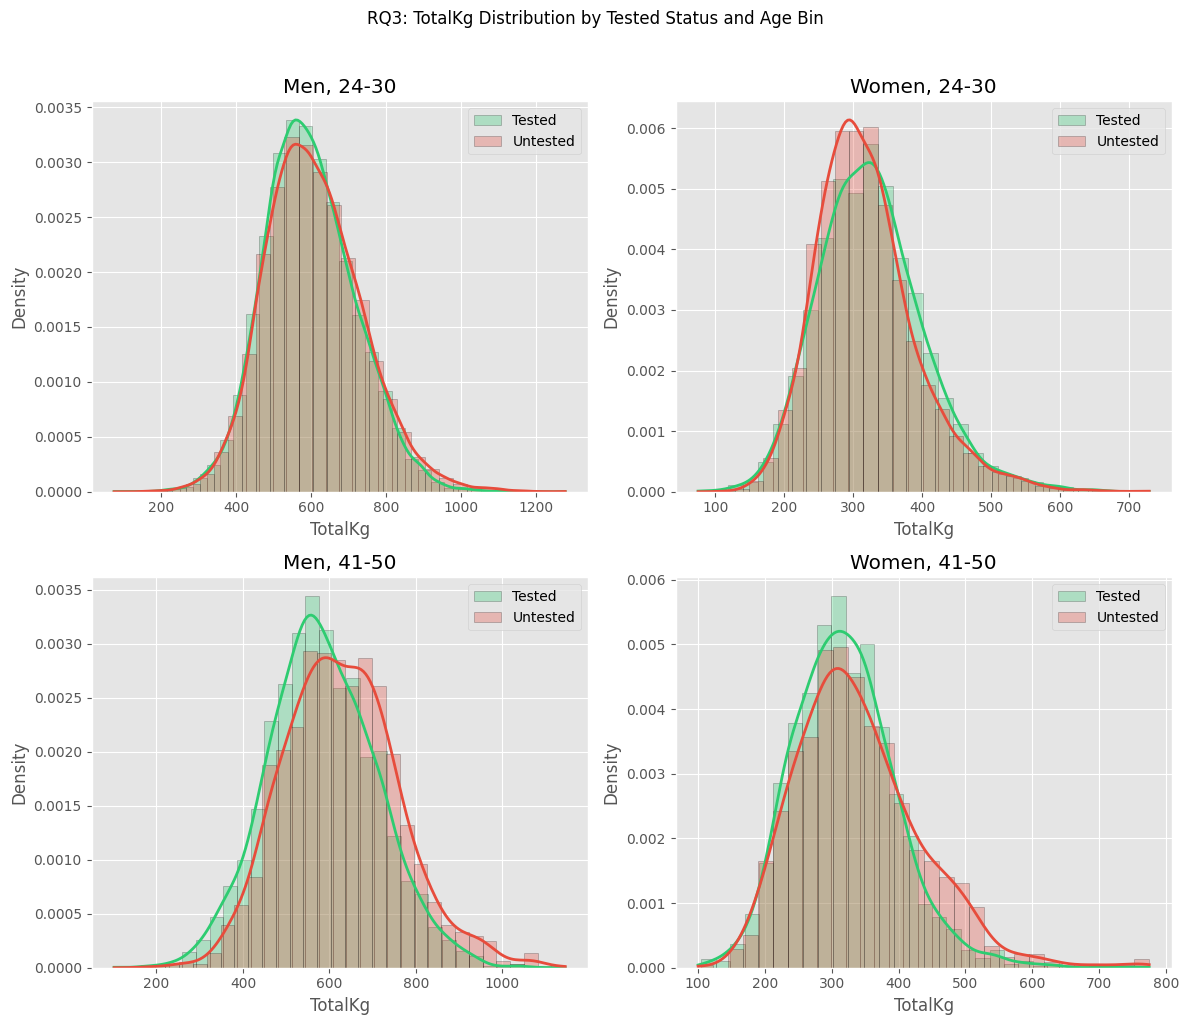

In [153]:
# =============================================================================
# RQ3 TotalKg Distributions by Tested Status (KDE)
# For two representative age bins (24-30 and 41-50), plot the
# representative-row TotalKg distribution for tested and untested
# groups side by side for men and women. 
# Each panel overlays a histogram with a KDE curve fit
# using Silverman's rule bandwidth.
# =============================================================================
DEMO_AGE_BINS = ["24-30", "41-50"]

plt.figure(figsize=(12, 10))

panel_num = 0
for age_label in DEMO_AGE_BINS:
    for sex in ["M", "F"]:
        panel_num += 1
        plt.subplot(2, 2, panel_num)

        # Filter to this sex and age bin
        age_df = rq3_supported_df[
            (rq3_supported_df["Sex"] == sex) &
            (rq3_supported_df["age_bin"] == age_label)
        ]

        tested_vals = age_df[age_df["is_tested"] == True]["TotalKg"].values
        untested_vals = age_df[age_df["is_tested"] == False]["TotalKg"].values

        # Shared evaluation grid so both curves use the same x-axis
        all_vals = np.concatenate([tested_vals, untested_vals])
        x_values = np.linspace(all_vals.min(), all_vals.max(), 200)

        # KDE with Silverman's rule bandwidth
        kde_tested = gaussian_kde(tested_vals, bw_method="silverman")
        kde_untested = gaussian_kde(untested_vals, bw_method="silverman")

        # Histograms (normalized to density so they match the KDE scale)
        plt.hist(tested_vals, bins=30, density=True, alpha=0.3,
                 edgecolor="black", linewidth=0.5,
                 color="#2ecc71", label="Tested")
        plt.hist(untested_vals, bins=30, density=True, alpha=0.3,
                 edgecolor="black", linewidth=0.5,
                 color="#e74c3c", label="Untested")

        # KDE overlay curves
        plt.plot(x_values, kde_tested.evaluate(x_values),
                 color="#2ecc71", linewidth=2)
        plt.plot(x_values, kde_untested.evaluate(x_values),
                 color="#e74c3c", linewidth=2)

        sex_label = "Men" if sex == "M" else "Women"
        plt.title(f"{sex_label}, {age_label}")
        plt.xlabel("TotalKg")
        plt.ylabel("Density")
        plt.legend()

plt.suptitle("RQ3: TotalKg Distribution by Tested Status and Age Bin", y=1.02)
plt.tight_layout()
# plt.savefig("figures/rq3_totalkg_kde_by_age_bin.svg", bbox_inches="tight")
plt.show()

**Figure RQ3-1.** The height of each curve shows how common a representative-row `TotalKg` value is within that group. Where the two curves sit on top of each other, tested and untested representative rows posted similar totals; where one curve sits to the right, that side tended to have higher representative-row totals.

In [154]:
# =============================================================================
# RQ3 Bootstrap Gap Bounds and Interval Evidence
# For each Sex x age_bin pair, bootstrap the gap (untested mean minus tested mean)
# in representative-row TotalKg. The main directional check is the one-sided 95% lower
# bootstrap bound, and the 95th percentile is kept for the plotted whiskers.
# =============================================================================
rq3_results = []

for sex in ["M", "F"]:
    sex_df = rq3_supported_df[rq3_supported_df["Sex"] == sex].copy()

    for age_label in AGE_LABELS:
        age_df = sex_df[sex_df["age_bin"] == age_label]

        tested_vals = age_df[age_df["is_tested"] == True]["TotalKg"].dropna().values
        untested_vals = age_df[age_df["is_tested"] == False]["TotalKg"].dropna().values

        if min(len(tested_vals), len(untested_vals)) < MIN_COUNT:
            rq3_results.append({
                "Sex": sex,
                "age_bin": age_label,
                "n_tested": len(tested_vals),
                "n_untested": len(untested_vals),
                "gap_total": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "note": "below MIN_COUNT"
            })
            continue

        observed_gap = np.mean(untested_vals) - np.mean(tested_vals)

        boot_gaps = []
        for i in range(N_BOOTSTRAP):
            boot_tested = np.random.choice(tested_vals, size=len(tested_vals), replace=True)
            boot_untested = np.random.choice(untested_vals, size=len(untested_vals), replace=True)
            boot_gaps.append(np.mean(boot_untested) - np.mean(boot_tested))

        boot_gaps = np.array(boot_gaps)
        ci_low, ci_high = np.percentile(boot_gaps, [5, 95])

        rq3_results.append({
            "Sex": sex,
            "age_bin": age_label,
            "n_tested": len(tested_vals),
            "n_untested": len(untested_vals),
            "gap_total": observed_gap,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "note": ""
        })

rq3_results = pd.DataFrame(rq3_results)
display(rq3_results)

# Interval evidence summary for each age bin
print("")
print("=" * 65)
print("RQ3 Interval Evidence (one-sided 95% lower bootstrap bound)")
print("A positive gap means untested minus tested is above zero.")
print("When the lower bound is above zero, that bin supports")
print("    higher mean representative-row TotalKg for untested rows.")
print("=" * 65)
print("")

support_count = 0
total_count = 0

for sex in ["M", "F"]:
    sex_label = "Men" if sex == "M" else "Women"
    sex_rows = rq3_results[rq3_results["Sex"] == sex]
    print(f"\n--- {sex_label} ---")

    for _, row in sex_rows.iterrows():
        if pd.isna(row["gap_total"]):
            continue

        total_count += 1
        age_bin = row["age_bin"]
        gap = row["gap_total"]
        ci_lo = row["ci_low"]
        ci_hi = row["ci_high"]

        print(f"\n  {age_bin}: gap = {gap:.2f}, bootstrap range [{ci_lo:.2f}, {ci_hi:.2f}]")

        if ci_lo > 0:
            support_count += 1
            print(f"    The one-sided 95% lower bootstrap bound is above zero.")
            print(f"    This bin supports higher mean representative-row TotalKg for untested rows.")
        elif ci_hi < 0:
            print(f"    The bootstrap interval stays entirely below zero.")
            print(f"    In this bin, tested representative rows averaged higher in the sample.")
        else:
            print(f"    The one-sided 95% lower bootstrap bound is not above zero.")
            print(f"    This bin does not provide clear interval-based support for the untested-higher direction.")

print("")
print("=" * 65)

m_rows = rq3_results[rq3_results["Sex"] == "M"]
f_rows = rq3_results[rq3_results["Sex"] == "F"]
m_support = (m_rows["ci_low"] > 0).sum()
f_support = (f_rows["ci_low"] > 0).sum()
m_total = m_rows["gap_total"].notna().sum()
f_total = f_rows["gap_total"].notna().sum()

print(f"Summary: {support_count} of {total_count} age bins have a one-sided 95% lower bound above zero.")
print(f"  Men:   {m_support} of {m_total} bins show interval-based support.")
print(f"  Women: {f_support} of {f_total} bins show interval-based support.")

print("=" * 65)
print("")

,Sex,age_bin,n_tested,n_untested,gap_total,ci_low,ci_high,note
0,M,18-23,29890,6497,17.6378,14.8644,20.4604,
1,M,24-30,32031,18599,10.7254,8.7835,12.6379,
2,M,31-40,17140,11091,23.7359,21.1124,26.3950,
3,M,41-50,4009,1903,43.5187,37.4994,49.5579,
4,M,51-60,1367,510,40.3593,29.8470,50.8408,
5,M,61+,507,147,27.3722,9.4108,45.0521,
6,F,18-23,11045,1968,-1.2419,-4.1656,1.6416,
7,F,24-30,14265,7534,-7.7193,-9.4767,-5.9913,
8,F,31-40,8508,4904,1.7769,-0.6165,4.1053,
9,F,41-50,2170,1048,20.4291,15.0286,25.9106,



RQ3 Interval Evidence (one-sided 95% lower bootstrap bound)
A positive gap means untested minus tested is above zero.
When the lower bound is above zero, that bin supports
    higher mean representative-row TotalKg for untested rows.


--- Men ---

  18-23: gap = 17.64, bootstrap range [14.86, 20.46]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-row TotalKg for untested rows.

  24-30: gap = 10.73, bootstrap range [8.78, 12.64]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-row TotalKg for untested rows.

  31-40: gap = 23.74, bootstrap range [21.11, 26.39]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-row TotalKg for untested rows.

  41-50: gap = 43.52, bootstrap range [37.50, 49.56]
    The one-sided 95% lower bootstrap bound is above zero.
    This bin supports higher mean representative-row TotalKg

The bootstrap results make the age pattern much clearer. For men, all six age bins have a one-sided 95% lower bound above zero, so every male age bin supports higher mean representative-row `TotalKg` for untested rows. For women, only 41-50 and 51-60 clear that same threshold. The women's 24-30 bin goes the other way, with the bootstrap interval staying entirely below zero, so tested representative rows averaged higher there in the sample. The 61+ interval is much wider for both sexes, which matches the smaller counts seen earlier and is a reminder that sparse bins give less precise interval evidence. Overall, the age-based untested edge is clearer and more consistent for men than for women.

A quick note on why the bootstrap percentiles differ between RQ1 and RQ3. RQ1 used a two-sided interval (`[2.5, 97.5]`) because the goal there was to sort subgroups into three buckets (above zero, below zero, or including zero) alongside the formal one-sided tests. RQ3 uses only the 5th percentile as a one-sided lower bound because the bootstrap interval is doing the main evidential work here, and the question only needs to check whether the gap clears zero. Both research questions ask the same directional question; the percentile choice just reflects what role the interval plays in each section.

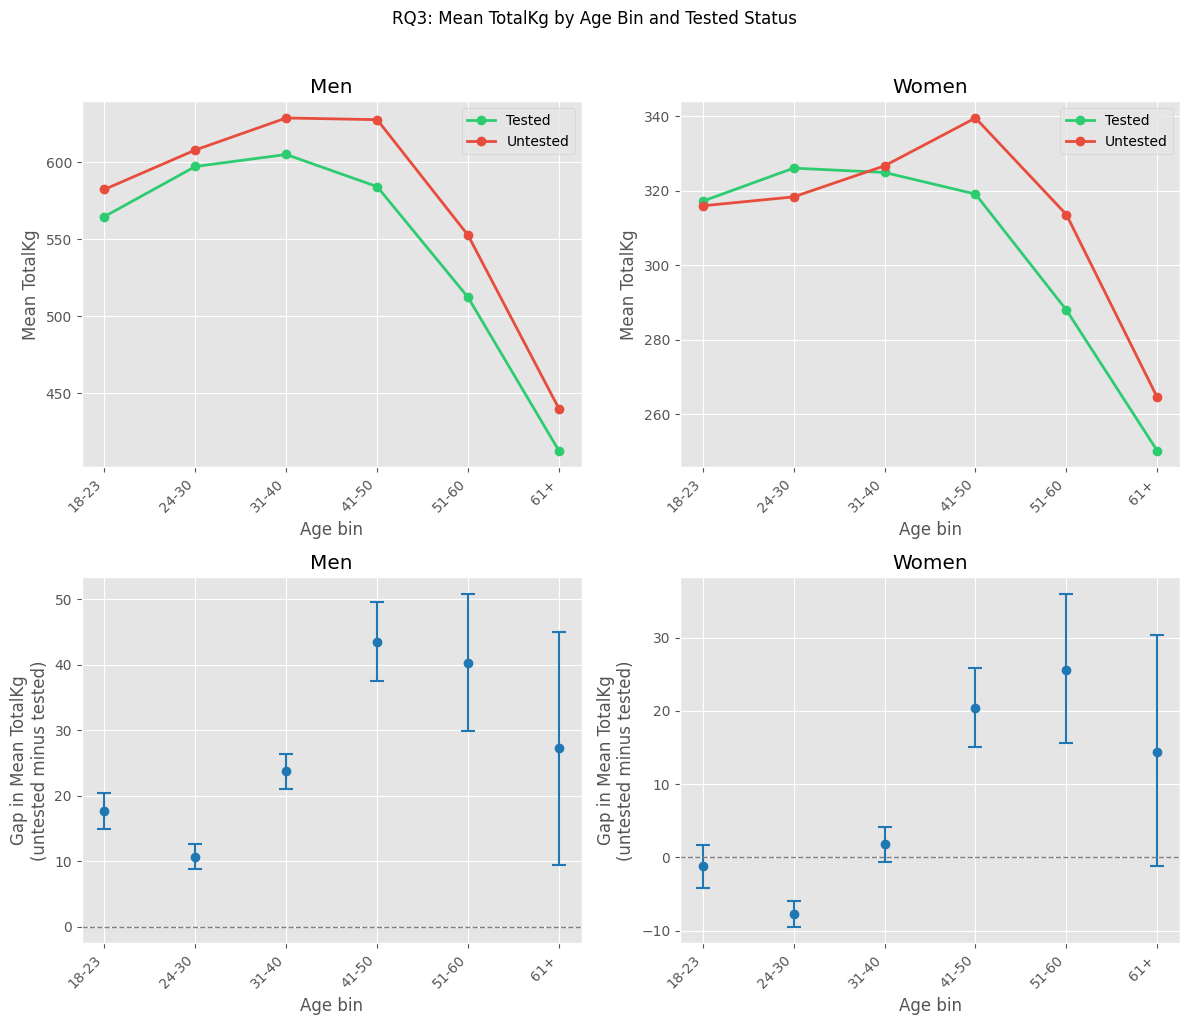

In [155]:
# =============================================================================
# RQ3 Mean TotalKg by Age Bin
# Top row: line chart comparing mean representative-row TotalKg for
# tested vs. untested groups across age bins, with separate panels
# for men and women.
# Bottom row: the gap (untested minus tested) with the one-sided 95%
# lower bootstrap bound as the lower whisker and the 95th percentile
# as the upper whisker for visual context.
# =============================================================================
age_summary = (
    rq3_supported_df
    .groupby(["Sex", "age_bin", "is_tested"])
    .agg(mean_total=("TotalKg", "mean"))
    .reset_index()
)

plt.figure(figsize=(12, 10))

panel_num = 0

for sex in ["M", "F"]:
    sex_summary = age_summary[age_summary["Sex"] == sex].copy()

    tested_line = sex_summary[sex_summary["is_tested"] == True].copy()
    untested_line = sex_summary[sex_summary["is_tested"] == False].copy()

    tested_line = tested_line.sort_values("age_bin")
    untested_line = untested_line.sort_values("age_bin")

    x = np.arange(len(AGE_LABELS))

    tested_y = []
    untested_y = []
    for age_label in AGE_LABELS:
        tested_match = tested_line[tested_line["age_bin"] == age_label]["mean_total"]
        untested_match = untested_line[untested_line["age_bin"] == age_label]["mean_total"]

        tested_y.append(tested_match.iloc[0] if len(tested_match) > 0 else np.nan)
        untested_y.append(untested_match.iloc[0] if len(untested_match) > 0 else np.nan)

    # ---- Top row: mean TotalKg lines ----
    panel_num += 1
    plt.subplot(2, 2, panel_num)
    plt.plot(x, tested_y, marker="o", linewidth=2, label="Tested", color="#2ecc71")
    plt.plot(x, untested_y, marker="o", linewidth=2, label="Untested", color="#e74c3c")
    plt.xticks(x, AGE_LABELS, rotation=45, ha="right")
    plt.xlabel("Age bin")
    plt.ylabel("Mean TotalKg")
    plt.title("Men" if sex == "M" else "Women")
    plt.legend()

for sex in ["M", "F"]:
    sex_results = rq3_results[rq3_results["Sex"] == sex].copy()

    x = np.arange(len(AGE_LABELS))

    gap_y = []
    ci_lo_list = []
    ci_hi_list = []
    for age_label in AGE_LABELS:
        row = sex_results[sex_results["age_bin"] == age_label]
        if len(row) > 0 and pd.notna(row.iloc[0]["gap_total"]):
            gap_y.append(row.iloc[0]["gap_total"])
            ci_lo_list.append(row.iloc[0]["ci_low"])
            ci_hi_list.append(row.iloc[0]["ci_high"])
        else:
            gap_y.append(np.nan)
            ci_lo_list.append(np.nan)
            ci_hi_list.append(np.nan)

    gap_y = np.array(gap_y)
    ci_lo_arr = np.array(ci_lo_list)
    ci_hi_arr = np.array(ci_hi_list)

    # Error bars: distance from the gap to each CI bound
    yerr_low = gap_y - ci_lo_arr
    yerr_high = ci_hi_arr - gap_y

    # ---- Bottom row: gap with CI whiskers ----
    panel_num += 1
    plt.subplot(2, 2, panel_num)
    plt.errorbar(x, gap_y, yerr=[yerr_low, yerr_high],
                 fmt="o", capsize=5, linewidth=2, color="#1f77b4",
                 ecolor="#1f77b4", elinewidth=1.5, capthick=1.5)
    plt.axhline(0, linestyle="--", color="gray", linewidth=1)
    plt.xticks(x, AGE_LABELS, rotation=45, ha="right")
    plt.xlabel("Age bin")
    plt.ylabel("Gap in Mean TotalKg\n(untested minus tested)")
    plt.title("Men" if sex == "M" else "Women")

plt.suptitle("RQ3: Mean TotalKg by Age Bin and Tested Status", y=1.02)
plt.tight_layout()
# plt.savefig("figures/rq3_mean_totalkg_by_age_bin.svg", bbox_inches="tight")
plt.show()

**Figure RQ3-2.** Mean representative-row TotalKg by age bin and tested status, shown separately for men (left) and women (right). The top row plots the mean representative-row TotalKg for tested (green) and untested (red) rows in each of six age bins. The bottom row shows the gap (untested mean minus tested mean) in representative-row TotalKg for each bin. The lower whisker marks the one-sided 95% lower bootstrap bound used for the interval evidence check, and the upper whisker shows the matching 95th percentile for visual context. The dashed gray line at zero marks the point of no difference.

### RQ3 Conclusion  

**Among representative rows with known age / assigned age bin, untested rows tended to post higher mean `TotalKg` than tested rows for men at every age bin. For women, the picture stayed mixed: younger bins showed little separation or tilted toward tested rows, while the clearest untested advantage appeared in middle age.**

The interval evidence supports the untested-higher direction in 8 of 12 age bins. For men, all six bins had a one-sided 95% lower bootstrap bound above zero, so every male age bin supported higher mean `TotalKg` for untested representative rows. For women, only 2 of 6 bins (41-50 and 51-60) showed that same pattern. In the 24-30 bin, the bootstrap interval stayed entirely below zero, meaning tested representative rows averaged higher than untested representative rows in that age range.

The representative-row distribution shapes in Figure RQ3-1 match that pattern. In the 41-50 bin the untested curve sits clearly to the right for both sexes. In the 24-30 bin the curves overlap almost completely for men, and for women the tested curve edges ahead.

Figure RQ3-2 shows how the representative-row gap changes with age:
- For men, the gap is moderate at 18-23 (~18 kg), dips at 24-30 (~11 kg), then widens through middle age, peaking around 41-50 (~44 kg).
- For women, the gap is near zero at 18-23, tilts toward tested at 24-30 (~8 kg in favor of tested), returns near zero at 31-40, then grows at 41-50 (~20 kg) and 51-60 (~26 kg). The 61+ bin trends the same way (~14 kg) but the lower bound is not above zero.
- In both sexes, whatever drives the tested/untested split is most visible in middle and older age groups.

## Overall Conclusion

No single story fits all three research questions. RQ1 still showed equipment-dependent patterns rather than a universal untested advantage even after the Bonferroni correction: Wraps consistently leaned toward untested entries, Single-ply leaned the other way in the sample, and Raw stayed mixed. RQ2 showed that the tested-entry share only fell below 50% in the highest DOTS bin, with much smaller separation across the rest of the score range. RQ3 showed age-dependent patterns, with the clearest untested edge appearing in middle and older age bins and much more consistently for men than for women. Taken together, the notebook points to competition context rather than one simple tested-versus-untested story. The `Tested` field is a label for competition context, not proof that any individual lifter did or did not use performance-enhancing drugs. The fact that Wraps and Single-ply move in opposite directions is another sign that testing policy is only one part of the broader competitive setting.

Across all three research questions, the study keeps only about 13% of the raw rows after cleaning, removes crossover lifters to keep the groups separate, and uses name-based crossover matching that may wrongly remove different lifters who share a name. RQ3 has extra limits because age is missing for 28.7% of the cleaned data, which makes its sample smaller than RQ1 and RQ2, and because the oldest bins, especially 61+, are sparse enough to widen the bootstrap ranges and reduce precision.
